06 · OSMnx: getting a street network in, and knowing what you have

First of five notebooks that treat the street network as the object of study
rather than as scenery under a city2graph result. This one is the download,
the cleaning, and the arithmetic that tells you what you got.

Which graph you have is decided by four settings:

* the download method: place, point, address, bounding box, polygon. Five
  ways of saying "Ciutat Vella, about 600 m", and five different graphs.
* `network_type`: `drive`, `bike`, `walk` and `all` give **243**, **814**,
  **1582** and **1894** intersections over the same disc of Valencia.
* simplification, which removes four nodes in every five.
* consolidation, which merges what is left, and can merge too much.

None is right or wrong on its own; not knowing which one you took is.

The study area is **Ciutat Vella, València** (39.4699, -0.3763) on a 600 m
radius: a few hundred kilobytes from Overpass rather than a few hundred
megabytes.

The next four: edge attributes, speeds and orientation (**11**), routing and
isochrones (**12**), accessibility and points of interest (**13**),
centrality and export (**14**). Elevation belongs to **08**.

## 0 · Setup

In [1]:
import importlib
import math
import pathlib
import sys
import time


def find_repo():
    """Locate the SciGraphs repository, without relying on the cwd.

    In a normal Jupyter the kernel starts per notebook with the cwd set to its
    folder. Not here: the kernel lives inside Blender and existed before you
    opened anything, so the cwd is wherever Blender was launched from. What the
    extension does know is which folder it is serving to JupyterLab.
    """
    candidates = []
    try:
        import bpy
        prefs = bpy.context.preferences.addons[
            "bl_ext.user_default.jupyter_blender"].preferences
        candidates.append(pathlib.Path(bpy.path.abspath(prefs.notebook_dir)))
    except Exception:
        pass
    candidates.append(pathlib.Path.cwd())

    for base in candidates:
        for directory in (base, *base.parents):
            if (directory / "SciGraphs" / "api" / "graphs.py").is_file():
                return directory

    raise RuntimeError(
        "Cannot find the SciGraphs repository. Point at it by hand:\n"
        "    sys.path.insert(0, '/path/to/SciGraphs-1/notebooks/tools')")


sys.path.insert(0, str(find_repo() / "notebooks" / "tools"))

import bpy
import geopandas as gpd
import networkx as nx
import numpy as np

# `nb` must import first: it puts this repository on sys.path, so the
# `SciGraphs` import below reads this tree, not the copy Blender installed.
import nb
from nb import check

from SciGraphs import api as sg

### The cache goes first, before anything downloads

`nb.osmnx()` sets `ox.settings.use_cache` **and**
`ox.settings.cache_folder`. The add-on sets only the first
(`SciGraphs/core/city2graph/data.py:47`), and the `osmnx_cache_directory`
preference defaults to empty, so OSMnx falls back to a **relative** path
resolved against wherever Blender was launched from: run the notebook from
two places and you have two caches, neither ever hit twice.

Overpass is a shared public service with a per-IP slot limit. Re-downloading
on every run collects an `HTTP 429`, then `Errno 111 Connection refused`,
then an outright failure that reads like a bug in the code. With the cache, a
re-run is offline in fifteen seconds.

Call it **before the first operator**, not merely before the first `ox.`
call: the importer imports the same `osmnx` module object this notebook does,
so whatever `cache_folder` says when the operator runs is where it looks.

In [2]:
ox = nb.osmnx()

print(f"osmnx        {ox.__version__}")
print(f"use_cache    {ox.settings.use_cache}")
print(f"cache_folder {nb.rel(ox.settings.cache_folder)}")

CACHE_DIR = pathlib.Path(ox.settings.cache_folder)
responses = sorted(CACHE_DIR.glob("*.json")) if CACHE_DIR.is_dir() else []
print(f"{len(responses)} cached Overpass responses, "
      f"{sum(p.stat().st_size for p in responses) / 1e6:.1f} MB")

osmnx        2.0.7
use_cache    True
cache_folder notebooks/data/cache/osmnx
47 cached Overpass responses, 81.5 MB


### The study area, and why the modules come from the add-on

The operators run inside the copy of SciGraphs that **Blender registered**,
and the graph they leave behind lives in a module-level dict inside *that*
copy. `import SciGraphs` reaches a different module object with an
empty cache, and every `get_osmnx_graph` would come back `None` (notebook 11
has the detail), so everything below reaches for the installed package by
name.

In [3]:
CENTER = (39.4699, -0.3763)      # Ciutat Vella, València
RADIUS_M = 600
PLACE = "Ciutat Vella, València, Spain"
ADDRESS = "Plaça de la Reina, València, Spain"

INSTALLED = next(k for k in bpy.context.preferences.addons.keys()
                 if k.rsplit(".", 1)[-1].lower() == "scigraphs")
graph_cache = importlib.import_module(INSTALLED + ".core.osmnx.graph_cache")
# `scigraphs_core` is a wheel: one copy in site-packages, shared by the notebook
# and the operators, so the installed/working-tree split does not apply to it.
convert = importlib.import_module("scigraphs_core.osmnx.convert")
geocoder = importlib.import_module("scigraphs_core.osmnx.geocoder")
mesh_bridge = importlib.import_module("scigraphs_core.osmnx.mesh_bridge")
sg_cache = importlib.import_module(INSTALLED + ".core.osmnx.cache")
sg_importer = importlib.import_module(INSTALLED + ".core.data_io.importer")
sg_geometry = importlib.import_module(INSTALLED + ".core.mesh.geometry")

print("add-on package :", INSTALLED)
print("graphml cache  :", nb.rel(sg_cache.get_cache_directory()))

add-on package : bl_ext.user_default.scigraphs
graphml cache  : ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache


### Four helpers, and why each has to exist

`download(...)` fires `scigraphs.import_osm_graph`. The operator reads *all*
the OSMnx properties off `scene.scigraphs`, so a property left set by an
earlier cell is the easiest way to get a graph you did not ask for. This
resets the lot, every time.

`materialize(G, name)` builds a Blender object from a NetworkX graph. The
cleaning operators replace the graph **in the in-memory cache and nowhere
else** and leave the mesh at its old node and edge counts (section 3), so
rebuilding is the only way to draw what they produced.

`node_attribute(...)` puts a per-node quantity on the mesh so a figure can be
colored by it. `mesh_bridge.transfer_node_attribute_to_mesh` does the first
half only. An OSMnx mesh has many more vertices than nodes, because
`retain_geometry` stores the shape of every street as intermediate points,
and that function leaves every one at `0.0`: they get no node glyph but they
do land in the attribute's range, so the color scale starts at a value no
intersection has. Here each takes the mean of the two intersections its
street runs between, the convention Blender uses when averaging edge
attributes onto points.

`counts(G)` prints three numbers the same way every time, so fifteen graphs
can be compared down a column.

In [4]:
def download(method='POINT', network_type='drive', simplify=True,
             retain_all=False, truncate_by_edge=True, place='', address='',
             bbox=None, distance=RADIUS_M, center=CENTER, polygon_object=''):
    """Set every OSMnx scene property, then run `scigraphs.import_osm_graph`.

    `bbox` is `(west, south, east, north)`, the order OSMnx 2.x uses
    everywhere and the order section 1 shows the add-on's own helper does not.
    Returns the new object, or None when the download failed.
    """
    props = bpy.context.scene.scigraphs
    props.osmnx_download_method = method
    props.osmnx_network_type = network_type
    props.osmnx_simplify = bool(simplify)
    props.osmnx_retain_all = bool(retain_all)
    props.osmnx_truncate_by_edge = bool(truncate_by_edge)
    props.osmnx_retain_geometry = True
    props.osmnx_custom_filter_preset = 'NONE'
    props.osmnx_custom_filter_text = ""
    props.osmnx_which_result = 0
    props.osmnx_scale = 0.001
    props.osmnx_place_name = place
    props.osmnx_address = address
    props.osmnx_polygon_object = polygon_object
    props.osmnx_latitude, props.osmnx_longitude = center
    props.osmnx_distance = int(distance)
    if bbox is not None:
        (props.osmnx_bbox_west, props.osmnx_bbox_south,
         props.osmnx_bbox_east, props.osmnx_bbox_north) = bbox

    started = time.time()
    try:
        result = bpy.ops.scigraphs.import_osm_graph()
    except RuntimeError as exc:          # the operator reports and cancels
        print(f"  import_osm_graph failed: {exc}")
        return None
    if 'FINISHED' not in result:
        return None
    obj = bpy.context.active_object
    obj["download_seconds"] = round(time.time() - started, 2)
    return obj


def materialize(G, name, scale=0.001):
    """A Blender object for a NetworkX graph an operator handed back.

    `create_osmnx_graph_object` reads `x`/`y` as longitude and latitude without
    checking (`_convert_osmnx_coords_to_3d` in
              `SciGraphs/core/mesh/geometry.py`), so a projected graph has to go back to
    EPSG:4326 first (section 4).
    """
    graph_data, geometries = sg_importer.osmnx_to_graph_data(
        G, retain_geometry=True)
    if graph_data is None:
        return None
    obj = sg_geometry.create_osmnx_graph_object(
        graph_data, geometries, scale=scale, retain_geometry=True)
    if obj is None:
        return None
    obj.name = name
    graph_cache.store_osmnx_graph(obj, G)
    obj["osmnx_scale"] = scale
    return obj


def node_attribute(obj, values, name):
    """Write a per-node quantity onto the mesh, filling the street geometry.

    `values` maps node id -> number. Returns (intersections written, array).
    """
    mesh = obj.data
    ids = str(obj.get("nodes_data", "")).split(",")
    array = np.zeros(len(mesh.vertices), dtype=np.float64)
    filled = np.zeros(len(mesh.vertices), dtype=bool)
    touched = np.zeros(len(mesh.vertices), dtype=bool)

    def key(text):
        return int(text) if text.lstrip("-").isdigit() else text

    for index, node_id in enumerate(ids):
        if index >= len(array):
            break
        value = values.get(key(node_id))
        if value is not None:
            array[index] = float(value)
            filled[index] = touched[index] = True

    # Shape vertices take the mean of the two intersections they connect.
    edge_verts = np.empty(len(mesh.edges) * 2, dtype=np.int32)
    mesh.edges.foreach_get("vertices", edge_verts)
    edge_verts = edge_verts.reshape(-1, 2)
    for (u, v), indices in mesh_bridge.build_edge_mapping(obj).items():
        a, b = values.get(key(u)), values.get(key(v))
        if a is None or b is None:
            continue
        middle = 0.5 * (float(a) + float(b))
        for edge_index in indices:
            for vertex in edge_verts[edge_index]:
                if not touched[vertex]:
                    array[vertex] = middle
                    touched[vertex] = True

    # Untouched vertices are geometry whose graph edge the mapping missed: a
    # self-loop or a parallel pair. Zero would plant a value no intersection
    # has at the bottom of every color ramp, so use the mean.
    real = array[filled]
    if len(real) and not touched.all():
        array[~touched] = float(real.mean())

    if name in mesh.attributes:
        mesh.attributes.remove(mesh.attributes[name])
    layer = mesh.attributes.new(name=name, type='FLOAT', domain='POINT')
    layer.data.foreach_set("value", array.astype(np.float32).tolist())
    return int(filled.sum()), array


def counts(G, label=""):
    """`(nodes, edges, kilometers)` for a graph, optionally on one printed line."""
    kilometers = sum(float(d.get("length", 0.0))
                     for *_ids, d in G.edges(data=True)) / 1000.0
    if label:
        print(f"  {label:<30} {G.number_of_nodes():>6} nodes "
              f"{G.number_of_edges():>6} edges {kilometers:>8.1f} km")
    return G.number_of_nodes(), G.number_of_edges(), kilometers


sg.graphs.clear_scene(keep_anchor=False)
props = bpy.context.scene.scigraphs
print("scene cleared")

scene cleared


## 1 · Five ways to say where

`osmnx_download_method` takes seven values. Five describe an area, and they
are not interchangeable.

| Method | You give it | Good for | Fails when |
|---|---|---|---|
| `PLACE` | `"Ciutat Vella, València, Spain"` | administrative units: a district, a municipality, a park | the geocoder returns the wrong one of six matches, or a point where you wanted a polygon |
| `POINT` | a lat/lon and a radius | *"this much around here"*: unambiguous, reproducible, no geocoder | the interesting area is not a disc |
| `ADDRESS` | a postal address and a radius | a study centered on a building | the address geocodes to the street rather than the number |
| `BBOX` | four numbers | matching somebody else's extent exactly: a raster tile, a published figure | you have to know the four numbers |
| `POLYGON` | a Blender mesh | a boundary you already have, or one you drew | the mesh vertices are not lon/lat |

The two left over: `MULTI_PLACE` unions a list of names, and `XML` reads a
local `.osm` file and touches no network at all, which is what to reach for
when Overpass is refusing connections.

**`PLACE` and `ADDRESS` cost two round trips**: Nominatim to resolve the
name, then Overpass for the data, and the first can silently give you a
different place next month. `POINT` and `BBOX` cost one and are
deterministic, which is why every reproducible pipeline in this suite is
built on `POINT`.

### The coordinates that go over the wire are not the ones you type

`props.osmnx_latitude` is a Blender `FloatProperty`, **single precision**.
`39.4699` has no exact 32-bit representation, so `ox.graph_from_point`
receives `39.46989822387695`, about twenty centimeters south of where you
asked, and `-0.3763` becomes `-0.37630000710487366`.

Two consequences, neither of them reported anywhere.

1. **The cache misses.** OSMnx keys its response cache on a hash of the
   Overpass query string, which contains the bounding box computed from these
   numbers, so a cache warmed by calling `ox.graph_from_point(CENTER, …)` by
   hand is one the operator never hits: the notebook downloads on every run
   while looking as if it caches.
2. **The graph is different.** Not merely renumbered: a shifted box crosses
   different ways, and the counts move.

In [5]:
props.osmnx_latitude, props.osmnx_longitude = CENTER
queried = (props.osmnx_latitude, props.osmnx_longitude)
meters_per_degree = 111320.0

print(f"asked for    {CENTER[0]!r}, {CENTER[1]!r}")
print(f"queried with {queried[0]!r}, {queried[1]!r}")
print(f"offset       {abs(queried[0] - CENTER[0]) * meters_per_degree * 100:.2f} cm "
      f"north-south, "
      f"{abs(queried[1] - CENTER[1]) * meters_per_degree * math.cos(math.radians(CENTER[0])) * 100:.2f} cm "
      f"east-west")

exact = ox.graph_from_point(CENTER, dist=RADIUS_M, network_type='drive',
                            simplify=True, truncate_by_edge=True)
counts(exact, "float64, calling OSMnx by hand")

net = download('POINT', 'drive')
net.name = "Net_point_drive"
G_point = graph_cache.get_osmnx_graph(net)
counts(G_point, "float32, through the operator")

check("the operator's graph is in the scene",
      net is not None and bool(net.get("is_osmnx")))
check("single precision changes the graph, not just the query string",
      exact.number_of_nodes() != G_point.number_of_nodes(),
      f"{exact.number_of_nodes()} vs {G_point.number_of_nodes()} nodes from "
      "the same request typed two ways")

asked for    39.4699, -0.3763
queried with 39.46989822387695, -0.37630000710487366
offset       19.77 cm north-south, 0.06 cm east-west
  float64, calling OSMnx by hand    242 nodes    373 edges     31.6 km

  Point: (39.46989822387695, -0.37630000710487366), radius: 600m
  Download completed in 0.40s
Total import time: 0.43s
  Nodes: 243, Edges: 375

Creating OSMnx graph: 243 nodes, 375 edges...
  Created 243 intersection vertices
  Created 361 street edges in 0.01s
Total OSMnx graph creation time: 0.01s
Graph saved to ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/39.4699_-0.3763_drive.graphml
Graph cached to: ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/39.4699_-0.3763_drive.graphml
Info: Downloading network from OpenStreetMap (POINT)...
Info: Graph cached as: 39.4699_-0.3763_drive.graphml
Info: Imported: 243 intersections, 375 street segments, 31.8 km total
  float32, through the operator     243 nodes    375 edges     31.8 km
[PASS] the operator's graph i

True

The fix is to warm the cache **through the operator**, as every
cell below does, and to treat the float32 value as the reproducible
identifier for a point download. Notebook 11 makes the same point from the
terrain side, where the rounding decides which DEM tile is fetched.

### What the imported object carries

The import writes a mesh and a dozen custom properties. Four are
load-bearing: `nodes_data` and `edges_data` carry any attribute back onto the
mesh, and `osmnx_center_lat`/`lon` is the projection origin anything placed
alongside the graph has to share.

In [6]:
for key in ("num_nodes", "num_edges", "total_length_m", "num_mesh_verts",
            "osmnx_center_lat", "osmnx_center_lon", "osmnx_scale",
            "osmnx_method", "osmnx_network_type", "osmnx_query_name",
            "is_directed"):
    print(f"  {key:<20} {net.get(key)}")
print(f"  {'mesh vertices':<20} {len(net.data.vertices)}")
print(f"  {'mesh edges':<20} {len(net.data.edges)}")
print("  attributes:", [(a.name, a.domain) for a in net.data.attributes
      if not a.name.startswith(".")])

  num_nodes            243
  num_edges            375
  total_length_m       31782.730552268284
  num_mesh_verts       1374
  osmnx_center_lat     39.46885868888891
  osmnx_center_lon     -0.3761819053497941
  osmnx_scale          0.0010000000474974513
  osmnx_method         POINT
  osmnx_network_type   drive
  osmnx_query_name     39.4699_-0.3763
  is_directed          True
  mesh vertices        1374
  mesh edges           1492
  attributes: [('is_intersection', 'POINT'), ('position', 'POINT')]


> **The trap that decides whether a figure is legible.**
> `create_osmnx_graph_object` writes `nodes_data`, `edges_data`,
> `osmnx_center_lat` and the rest of the native-graph contract, but **not**
> `node_positions` (`SciGraphs/core/mesh/geometry.py:1750`). `sg.preview.extent`,
> and through it every node radius and every camera fit, falls back to *all*
> mesh vertices, which here means every sample along every street centerline.
> The median nearest-neighbor distance then measures the sampling step of
> the road geometry rather than the distance between intersections, and the
> node radius derived from it is several times too small: a two-pixel node
> and a sub-pixel tube.
>
> `sg.render.node_cloud()` reads the `is_intersection` vertex layer instead,
> which `create_osmnx_graph_object` *does* write. Every figure below goes
> through `nb.render`, which measures through `node_cloud`.

In [7]:
cloud, source = sg.render.node_cloud(net)
_center, _size, _diagonal, median_nn = sg.render.measure(net)[0]
_c, _s, _d, naive_nn = sg.preview.extent(net)
scale = float(net.get("osmnx_scale", 0.001))

print(f"node_positions present   {'node_positions' in net.keys()}")
print(f"node_cloud source        {source}  ({len(cloud)} of "
      f"{len(net.data.vertices)} vertices)")
print(f"median nearest neighbor {median_nn / scale:>6.1f} m  through node_cloud")
print(f"                         {naive_nn / scale:>6.1f} m  over every vertex")
print(f"node radius would be     "
      f"{median_nn * sg.render.NODE_FRACTION / scale:>6.1f} m  vs "
      f"{naive_nn * sg.render.NODE_FRACTION / scale:.1f} m, a factor of "
      f"{median_nn / naive_nn:.1f}")

check("the node cloud is the intersections, not the street geometry",
      source == "is_intersection" and len(cloud) == net.get("num_nodes"))

node_positions present   False
node_cloud source        is_intersection  (243 of 1374 vertices)
median nearest neighbor   35.1 m  through node_cloud
                            6.1 m  over every vertex
node radius would be       12.3 m  vs 2.1 m, a factor of 5.7
[PASS] the node cloud is the intersections, not the street geometry


True

### Resolving a name: the two geocoders

`osmnx_geocode` turns a place name or an address into a lat/lon and writes it
straight into `osmnx_latitude`/`osmnx_longitude`, which is how a `PLACE`
question becomes a reproducible `POINT` download. `osmnx_geocode_to_gdf`
fetches the boundary **polygon** instead, which is what `POLYGON` wants.

In [8]:
coords = geocoder.geocode(ADDRESS)
print(f"geocode({ADDRESS!r})\n  -> {coords}")

boundary = geocoder.geocode_to_gdf(PLACE)
print(f"\ngeocode_to_gdf({PLACE!r})")
if boundary is not None and len(boundary):
    print(f"  {len(boundary)} feature(s), crs {boundary.crs}, "
          f"{boundary.geometry.iloc[0].geom_type}")
    print(f"  bounds {[round(v, 5) for v in boundary.total_bounds]}")
    print(f"  area   {boundary.to_crs('EPSG:25830').area.sum() / 1e6:.3f} km2")

check("the address geocodes", coords is not None)
check("the place has a boundary polygon",
      boundary is not None and len(boundary) > 0)

Geocoded 'Plaça de la Reina, València, Spain' to (39.474484, -0.3754586)
geocode('Plaça de la Reina, València, Spain')
  -> (39.474484, -0.3754586)
Geocoded 'Ciutat Vella, València, Spain' to GeoDataFrame

geocode_to_gdf('Ciutat Vella, València, Spain')
  1 feature(s), crs epsg:4326, Polygon
  bounds [np.float64(-0.38416), np.float64(39.46712), np.float64(-0.36601), np.float64(39.48214)]
  area   1.721 km2
[PASS] the address geocodes
[PASS] the place has a boundary polygon


True

> **Defect.** `osmnx_geocode_to_gdf` throws the GeoDataFrame
> away (`SciGraphs/ui/operators/osmnx/geocoding_operators.py:28-36`): it
> fetches the boundary, reports how many features came back, and returns
> `{'FINISHED'}` with nothing written to the scene, to an object, or to disk.
> The core function is fine (the cell above calls it); the button spends a
> Nominatim request and produces no result.

### `osmnx_bbox_from_point`, which has two faults stacked

The button that turns a point and a radius into the four `BBOX` fields writes
**90, 90, 180, 180**: the maxima of the four properties, and not a box at
all. Two independent faults produce that, and only one of them is visible.

**The projection fires first.** `core/osmnx/utils_geo.py:5` gives
`bbox_from_point` a default of `project_utm=True`, where OSMnx's own default
is `False`, and the operator does not pass the argument
(`geocoding_operators.py:79`). The wrapper asks for the box in **UTM
meters**, numbers in the hundreds of thousands, and hands them to four
`FloatProperty` fields clamped to ±90 and ±180 degrees. Every one saturates.

**The ordering is underneath.** `ox.utils_geo.bbox_from_point` in OSMnx 2.x
returns `(left, bottom, right, top)`, that is `(west, south, east, north)`;
the operator assigns `bbox[0]` to `osmnx_bbox_north`, `bbox[1]` to south,
`bbox[2]` to east and `bbox[3]` to west (`geocoding_operators.py:87-90`), the
OSMnx 1.x order. Fix the projection and this takes over: north receives the
longitude of the western edge and west the latitude of the northern edge.

The *download* path is correct: `_osmnx_graph_from_bbox` switches on the
OSMnx major version and reorders (`core/data_io/importer.py:542-557`). A
`BBOX` download works, unless the four numbers came from the button next to
it.

In [9]:
west, south, east, north = ox.utils_geo.bbox_from_point(CENTER, dist=RADIUS_M)
print(f"ox.utils_geo.bbox_from_point            -> (W, S, E, N) = "
      f"({west:.5f}, {south:.5f}, {east:.5f}, {north:.5f})")
projected = ox.utils_geo.bbox_from_point(CENTER, dist=RADIUS_M,
                                         project_utm=True)
print(f"…the same call with project_utm=True    -> "
      f"{tuple(round(v) for v in projected)}  (UTM meters)")

print("\nosmnx_bbox_from_point ->",
      bpy.ops.scigraphs.osmnx_bbox_from_point(
      latitude=CENTER[0], longitude=CENTER[1], distance=float(RADIUS_M)))
wrote = (props.osmnx_bbox_north, props.osmnx_bbox_south,
         props.osmnx_bbox_east, props.osmnx_bbox_west)
print(f"  wrote N={wrote[0]:.5f}  S={wrote[1]:.5f}  "
      f"E={wrote[2]:.5f}  W={wrote[3]:.5f}")
print("  the property limits are ±90 and ±180, so every field saturated")

# The second fault, with the projection out of the way.
would_be = (west, south, east, north)     # what OSMnx 2.x returns
print(f"\nwith project_utm=False, the operator's own mapping would write")
print(f"  N={would_be[0]:.5f}  S={would_be[1]:.5f}  "
      f"E={would_be[2]:.5f}  W={would_be[3]:.5f}")
print(f"  a usable box needs N > S and E > W:  "
      f"N>S {would_be[0] > would_be[1]},  E>W {would_be[2] > would_be[3]}")

check("osmnx_bbox_from_point cannot produce a usable box",
      not (wrote[0] > wrote[1] and wrote[2] > wrote[3]),
      "UTM meters clamped to degree limits; and under that, north and "
      "west are swapped")
check("the ordering fault is real underneath the projection one",
      not (would_be[0] > would_be[1] and would_be[2] > would_be[3]),
      "read the tuple as (W, S, E, N), or call "
      "ox.utils_geo.bbox_from_point directly, as this notebook does")

ox.utils_geo.bbox_from_point            -> (W, S, E, N) = (-0.38329, 39.46450, -0.36931, 39.47530)
…the same call with project_utm=True    -> (725077, 4371594, 726315, 4372827)  (UTM meters)
Created bbox from point with 600.0m radius
Info: BBox created: 600.0m around point

osmnx_bbox_from_point -> {'FINISHED'}
  wrote N=90.00000  S=90.00000  E=180.00000  W=180.00000
  the property limits are ±90 and ±180, so every field saturated

with project_utm=False, the operator's own mapping would write
  N=-0.38329  S=39.46450  E=-0.36931  W=39.47530
  a usable box needs N > S and E > W:  N>S False,  E>W False
[PASS] osmnx_bbox_from_point cannot produce a usable box — UTM meters clamped to degree limits; and under that, north and west are swapped
[PASS] the ordering fault is real underneath the projection one — read the tuple as (W, S, E, N), or call ox.utils_geo.bbox_from_point directly, as this notebook does


True

### A boundary as a Blender mesh, for `POLYGON`

The `POLYGON` method reads a mesh object's **vertex coordinates as longitude
and latitude**: no transform, no CRS, no check
(`data_operators.py:562-573`). It takes the first face if there is one and
all the vertices otherwise, so the boundary from `geocode_to_gdf` becomes a
download boundary by being written into a mesh.

Two details that are not advertised. The polygon is simplified first, to
eleven points, because Overpass builds one clause per vertex and a
400-vertex administrative boundary takes minutes and is rejected under load.
And mesh coordinates are **float32**, so the boundary is quantized to about a
centimeter on the way in.

In [10]:
outline = boundary.geometry.iloc[0]
if outline.geom_type == 'MultiPolygon':
    outline = max(outline.geoms, key=lambda g: g.area)
ring = list(outline.simplify(0.0004).exterior.coords)[:-1]

aoi_mesh = bpy.data.meshes.new("AOI_Mesh")
aoi_mesh.from_pydata([(x, y, 0.0) for x, y in ring], [],
                     [list(range(len(ring)))])
aoi_mesh.update()
aoi = bpy.data.objects.new("AOI_CiutatVella", aoi_mesh)
bpy.context.scene.collection.objects.link(aoi)
aoi.hide_render = True

print(f"boundary       {len(outline.exterior.coords)} points")
print(f"simplified to  {len(ring)} points, which is {len(ring)} Overpass clauses")
print(f"as float32     {tuple(round(v, 6) for v in aoi_mesh.vertices[0].co[:2])} "
      f"vs {tuple(round(v, 6) for v in ring[0])}")

boundary       159 points
simplified to  11 points, which is 11 Overpass clauses
as float32     (-0.384156, 39.475712) vs (-0.384156, 39.47571)


### Five methods, five graphs

The same neighborhood asked for five ways, `network_type='drive'`
throughout. All five are recognizably Ciutat Vella.

In [11]:
methods = {}
methods['POINT'] = net
methods['PLACE'] = download('PLACE', place=PLACE)
methods['ADDRESS'] = download('ADDRESS', address=ADDRESS)
methods['BBOX'] = download('BBOX', bbox=(west, south, east, north))
methods['POLYGON'] = download('POLYGON', polygon_object=aoi.name)

print(f"  {'method':<30} {'nodes':>6}       {'edges':>6}       {'km':>8}")
for name, obj in list(methods.items()):
    if obj is None:
        print(f"  {name:<30} download failed: Overpass is refusing "
              "connections; wait and re-run")
        methods.pop(name)
        continue
    obj.name = f"Net_{name.lower()}"
    counts(graph_cache.get_osmnx_graph(obj), name)

check("all five ways of saying where came back",
      len(methods) == 5, f"{sorted(methods)}")
check("no two of them are the same graph",
      len({obj.get("num_nodes") for obj in methods.values()})
      == len(methods),
      "same place, five extents")


  Place: Ciutat Vella, València, Spain
  Download completed in 0.30s
Total import time: 0.33s
  Nodes: 236, Edges: 358

Creating OSMnx graph: 236 nodes, 358 edges...
  Created 236 intersection vertices
  Created 336 street edges in 0.01s
Total OSMnx graph creation time: 0.01s
Graph saved to ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/Ciutat_Vella_València_Spain_drive.graphml
Graph cached to: ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/Ciutat_Vella_València_Spain_drive.graphml
Info: Downloading network from OpenStreetMap (PLACE)...
Info: Graph cached as: Ciutat_Vella_València_Spain_drive.graphml
Info: Imported: 236 intersections, 358 street segments, 33.2 km total

  Address: Plaça de la Reina, València, Spain, radius: 600m
  Download completed in 0.30s
Total import time: 0.32s
  Nodes: 177, Edges: 264

Creating OSMnx graph: 177 nodes, 264 edges...
  Created 177 intersection vertices
  Created 246 street edges in 0.01s
Total OSMnx graph creation time: 0.01

True

`PLACE` and `POLYGON` follow the administrative boundary, not a
disc: they miss streets a few meters outside it and include a tail the 600 m
radius never reaches, which is why `PLACE` has *fewer* nodes than `POINT` and
*more* kilometers. `POLYGON` is smaller again because the eleven-point
simplification cuts corners off the same boundary. `ADDRESS` is the smallest
because Plaça de la Reina is half a kilometer from the center the others
used. `BBOX` and `POINT` are nominally the same square, because OSMnx builds
a point download's box exactly this way; they differ by one node, the float32
rounding arriving twice.

In [12]:
address_offset = math.hypot(
    (coords[0] - CENTER[0]) * meters_per_degree,
    (coords[1] - CENTER[1]) * meters_per_degree
    * math.cos(math.radians(CENTER[0])))
print(f"the address geocodes {address_offset:.0f} m from the point center")
print(f"the boundary polygon covers "
      f"{boundary.to_crs('EPSG:25830').area.sum() / 1e6:.2f} km2, against "
      f"{math.pi * (RADIUS_M / 1000) ** 2:.2f} km2 for the disc")
print(f"POINT and BBOX differ by "
      f"{abs(methods['POINT'].get('num_nodes') - methods['BBOX'].get('num_nodes'))} "
      "node(s)")

the address geocodes 515 m from the point center
the boundary polygon covers 1.72 km2, against 1.13 km2 for the disc
POINT and BBOX differ by 1 node(s)


Pick one and write it down: the reproducible-pipeline machinery
in notebook 19 puts this choice in a spec file with a hash rather than in
somebody's memory.

## 2 · `network_type`, measured

The dropdown has six entries, filters on the OSM `highway` tag. The same disc
of Valencia is a different graph under each one, and a statistic quoted
without its network type is not a statistic.

Four downloads, same center, same radius, same everything else.

In [13]:
NETWORK_TYPES = ('drive', 'bike', 'walk', 'all')

networks = {}
for network_type in NETWORK_TYPES:
    obj = download('POINT', network_type)
    if obj is None:
        print(f"  {network_type:<10} download failed; wait and re-run")
        continue
    obj.name = f"Net_{network_type}"
    networks[network_type] = obj

check("every network type came back", len(networks) == len(NETWORK_TYPES),
      f"{sorted(networks)}")


  Point: (39.46989822387695, -0.37630000710487366), radius: 600m
  Download completed in 0.41s
Total import time: 0.44s
  Nodes: 243, Edges: 375

Creating OSMnx graph: 243 nodes, 375 edges...
  Created 243 intersection vertices
  Created 361 street edges in 0.01s
Total OSMnx graph creation time: 0.01s
Graph saved to ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/39.4699_-0.3763_drive.graphml
Graph cached to: ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/39.4699_-0.3763_drive.graphml
Info: Downloading network from OpenStreetMap (POINT)...
Info: Graph cached as: 39.4699_-0.3763_drive.graphml
Info: Imported: 243 intersections, 375 street segments, 31.8 km total

  Point: (39.46989822387695, -0.37630000710487366), radius: 600m
  Download completed in 0.71s
Total import time: 0.81s
  Nodes: 814, Edges: 1,597

Creating OSMnx graph: 814 nodes, 1,597 edges...
  Created 814 intersection vertices
    Created 1,000 edges...
  Created 1,163 street edges in 0.09s
Total OSM

True

The table needs two length columns. **`counts()` sums the edges
of a `MultiDiGraph`, so a two-way street is counted twice**, and how much
double counting there is depends on the network type: this `drive` network is
almost entirely one-way, the `walk` network two-way everywhere. Comparing
directed totals across types compares one-way systems as much as street
provision. The undirected total is the one that means *meters of street*.

In [14]:
street_km = {}
print(f"  {'network_type':<10} {'nodes':>6} {'edges':>6} "
      f"{'directed km':>12} {'street km':>10} {'x drive':>8}")
for network_type, obj in networks.items():
    G = graph_cache.get_osmnx_graph(obj)
    nodes, edges, directed_km = counts(G)
    street_km[network_type] = counts(convert.to_undirected(G))[2]
    print(f"  {network_type:<10} {nodes:>6} {edges:>6} "
          f"{directed_km:>12.1f} {street_km[network_type]:>10.1f} "
          f"{nodes / networks['drive'].get('num_nodes'):>7.1f}x")

check("the directed total over-counts a two-way network",
      street_km['walk'] < 0.6 * counts(
      graph_cache.get_osmnx_graph(networks['walk']))[2],
      "every footway is bidirectional, so the walk network's edge length "
      "is close to twice its street length")

  network_type  nodes  edges  directed km  street km  x drive
Converted to undirected graph
  drive         243    375         31.8       31.0     1.0x
Converted to undirected graph
  bike          814   1597         73.0       54.2     3.3x
Converted to undirected graph
  walk         1582   4714        147.6       73.8     6.5x
Converted to undirected graph
  all          1894   5053        142.2       88.9     7.8x
[PASS] the directed total over-counts a two-way network — every footway is bidirectional, so the walk network's edge length is close to twice its street length


True

`walk` is not `drive` plus sidewalks. It is six and a half
times the intersections and, once the double counting is taken out, roughly
two and a half times the street length: every footpath, every flight of
steps, every pedestrian crossing modeled as a way, and in a medieval center
every alley a car cannot enter. A walking isochrone computed on a `drive`
graph is wrong by most of the network, and it will not look wrong.

`bike` sits between them and is the least stable of the four: it depends on
how thoroughly the local mapping community has tagged cycle infrastructure,
which the graph cannot tell you, so comparing `bike` across cities compares
mapping effort as much as provision.

`all` adds private driveways and service ways, real but not usually the
public network anyone is studying, and it is by some way the slowest to
download. The two entries not tested here, `drive_service` and `all_public`,
sit between `drive` and `all`; `all_public` is the honest default when the
question is *where can a person go* rather than *where can a car go*.

### The first figures

**Every figure here is EEVEE through `sg.render`, straight down through an
orthographic camera**: a street map read at an angle cannot be measured off
the page, and a perspective camera makes two equal blocks different sizes.
Node size is derived through `sg.render` for the `node_positions` reason
above.

The quantity here is `node_street_count`, the number of physical streets
meeting at each intersection, which OSMnx counts during simplification and
stores on the node. 1 is a dead end, 3 a T, 4 a crossroads. The look is
`ink`, whose colormap is turbo: a street network is thin bright lines on a
dark ground, and turbo runs dark blue to red without passing near that
ground.

The ramps are auto-ranged and printed under each figure. They are not
identical: the drive network has no six-way junction and the walking network
does. `vmin`/`vmax` are silently ineffective here anyway, for the reason set
out under **Rendering** at the end.

In [15]:
for network_type, obj in networks.items():
    G = graph_cache.get_osmnx_graph(obj)
    values = {n: d.get("street_count", 0) for n, d in G.nodes(data=True)}
    written, array = node_attribute(obj, values, "node_street_count")
    real = array[:obj.get("num_nodes")]
    print(f"  {network_type:<6} street_count on {written:>5} intersections, "
          f"{real.min():.0f} to {real.max():.0f}, "
          f"median {np.median(real):.0f}, "
          f"dead ends {100 * (real == 1).mean():.0f} %")

  drive  street_count on   243 intersections, 1 to 5, median 3, dead ends 2 %
  bike   street_count on   814 intersections, 1 to 6, median 3, dead ends 14 %
  walk   street_count on  1582 intersections, 1 to 6, median 3, dead ends 12 %
  all    street_count on  1894 intersections, 1 to 6, median 3, dead ends 5 %


  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> node_street_count  ·  node_street_count -> turbo [log]  [1 … 5] on Point


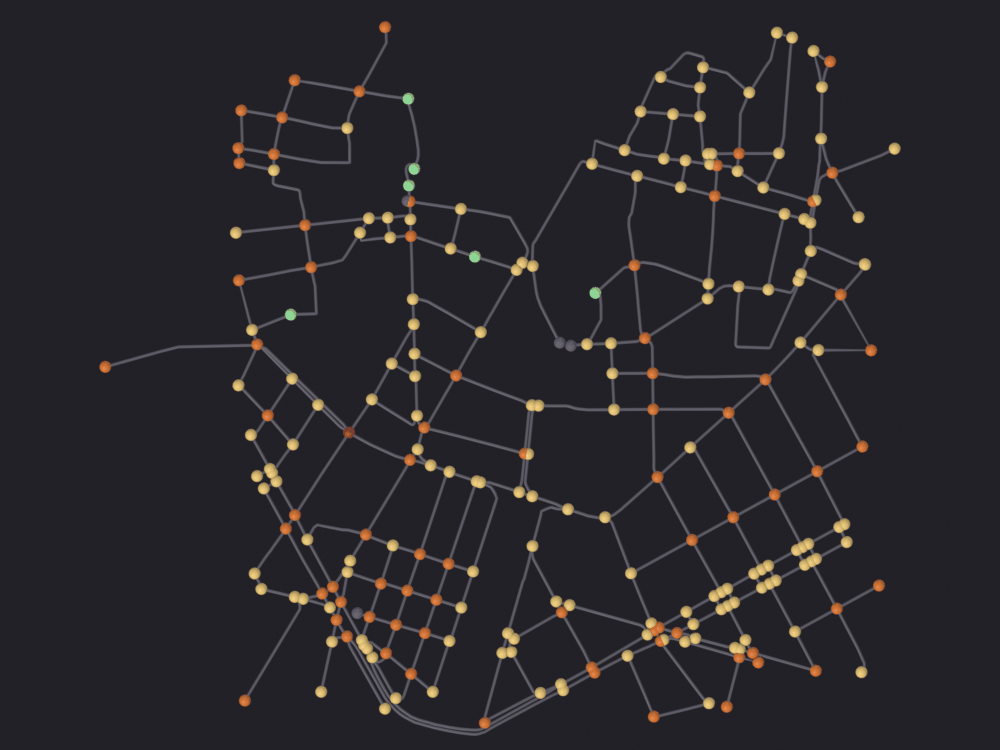

[PASS] 1_type_drive.png legible — 9.3% ink (healthy range 0.5–60%)
color range: (1.0, 5.0)


In [16]:
nb.figure(networks['drive'], "renders/06_osmnx/1_type_drive",
          look='ink', color_attribute="node_street_count")
print("color range:", sg.render.color_range(networks['drive']))

  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> node_street_count  ·  node_street_count -> turbo [log]  [1 … 6] on Point


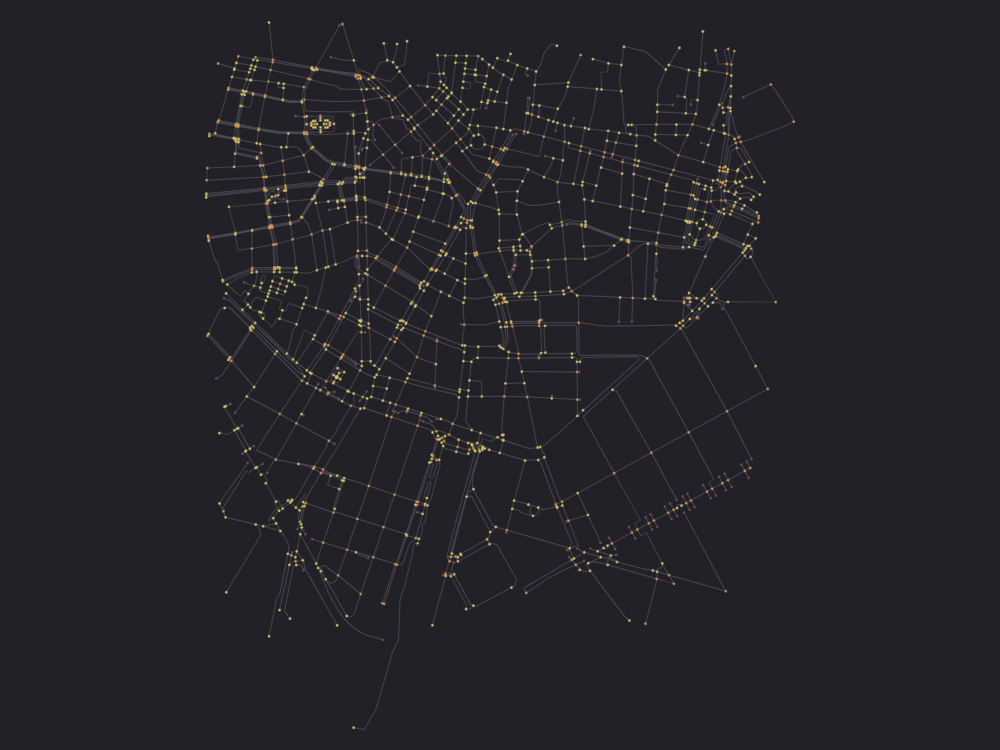

[PASS] 2_type_walk.png legible — 6.9% ink (healthy range 0.5–60%)
color range: (1.0, 6.0)


In [17]:
nb.figure(networks['walk'], "renders/06_osmnx/2_type_walk",
          look='ink', color_attribute="node_street_count")
print("color range:", sg.render.color_range(networks['walk']))

## 3 · Simplification

An OSM way is a polyline, and every vertex of it is a node in the raw graph.
Most are not junctions, they are the *shape* of the street. `simplify_graph`
removes them, merging each run of degree-2 nodes into a single edge whose
`geometry` attribute keeps the shape. What comes out is the graph every
street-network statistic in the literature is computed on: the raw one is a
drawing of the road centerlines, the simplified one is the topology.

In [18]:
raw = download('POINT', 'drive', simplify=False)
raw.name = "Net_drive_raw"
G_raw = graph_cache.get_osmnx_graph(raw)
counts(G_raw, "raw (simplify=False)")

sg.graphs.activate(raw)
print("osmnx_simplify ->", bpy.ops.scigraphs.osmnx_simplify())
G_after = graph_cache.get_osmnx_graph(raw)
counts(G_after, "after osmnx_simplify")
counts(G_point, "simplify=True on download")

simplified = materialize(G_after, "Net_drive_simplified")

removed = G_raw.number_of_nodes() - G_after.number_of_nodes()
print()
print(f"nodes removed   {removed} of {G_raw.number_of_nodes()} "
      f"({100 * removed / G_raw.number_of_nodes():.1f} %)")
print(f"mesh vertices   {len(raw.data.vertices)} -> {len(simplified.data.vertices)}")
print(f"of which nodes  {raw.get('num_nodes')} -> {simplified.get('num_nodes')}")
print(f"mean edge span  {1000 * counts(G_raw)[2] / G_raw.number_of_edges():.1f} m"
      f"  ->  {1000 * counts(G_after)[2] / G_after.number_of_edges():.1f} m")

check("simplification removes most of the nodes",
      G_after.number_of_nodes() < G_raw.number_of_nodes() / 3)
check("it does not remove any street",
      abs(counts(G_after)[2] - counts(G_raw)[2]) < 0.02 * counts(G_raw)[2],
      "the length is carried into the merged edges' geometry")


  Point: (39.46989822387695, -0.37630000710487366), radius: 600m
  Download completed in 0.24s
Total import time: 0.35s
  Nodes: 1,191, Edges: 1,330

Creating OSMnx graph: 1,191 nodes, 1,330 edges...
  Created 1,191 intersection vertices
    Created 1,000 edges...
  Created 1,283 street edges in 0.13s
Total OSMnx graph creation time: 0.14s
Graph saved to ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/39.4699_-0.3763_drive.graphml
Graph cached to: ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/39.4699_-0.3763_drive.graphml
Info: Downloading network from OpenStreetMap (POINT)...
Info: Graph cached as: 39.4699_-0.3763_drive.graphml
Info: Imported: 1191 intersections, 1330 street segments, 27.7 km total
  raw (simplify=False)             1191 nodes   1330 edges     27.7 km
Graph simplified: 1191 -> 254 nodes
Info: Simplified: 1191 -> 254 nodes
osmnx_simplify -> {'FINISHED'}
  after osmnx_simplify              254 nodes    358 edges     27.7 km
  simplify=True on do

True

### Two things that are not obvious

**The operator does not touch the mesh.** `osmnx_simplify` just reported a
fall of about a thousand nodes, and the object it ran on still has every one
of them as an intersection vertex: it replaced the graph in the in-memory
cache (`graph_operators.py:575-578`) and stopped there. So does every
operator in this family: `osmnx_consolidate`, `osmnx_largest_component`,
`osmnx_to_undirected`, `osmnx_to_digraph`, `osmnx_truncate_bbox`,
`osmnx_truncate_polygon`, `osmnx_truncate_distance`. That is what
`materialize()` is for.

In [19]:
print(f"the graph in the cache   {G_after.number_of_nodes()} nodes")
print(f"the mesh it ran on       {raw.get('num_nodes')} intersection vertices, "
      f"{len(raw.data.vertices)} vertices in all")
check("the cleaning operators leave the mesh untouched",
      raw.get("num_nodes") == G_raw.number_of_nodes()
      != G_after.number_of_nodes(),
      "so a render taken now would draw the unsimplified network")

the graph in the cache   254 nodes
the mesh it ran on       1191 intersection vertices, 1191 vertices in all
[PASS] the cleaning operators leave the mesh untouched — so a render taken now would draw the unsimplified network


True

**Simplifying afterwards is not the same as simplifying on
download**, and the difference is not rounding.
`graph_from_point(simplify=True)` simplifies *inside* the download pipeline,
before the boundary truncation has finished; `truncate_by_edge=True` then
keeps any edge with one endpoint inside the box, and a simplified edge spans
a whole block rather than a few meters, so it reaches much further past the
boundary and drags more network in behind it.

In [20]:
both = set(G_after.nodes) & set(G_point.nodes)
only_download = set(G_point.nodes) - set(G_after.nodes)
only_after = set(G_after.nodes) - set(G_point.nodes)


def median_radius(G, nodes):
    if not nodes:
        return float("nan")
    return float(np.median([
                 math.hypot((G.nodes[n]["y"] - CENTER[0]) * meters_per_degree,
                 (G.nodes[n]["x"] - CENTER[1]) * meters_per_degree
                 * math.cos(math.radians(CENTER[0])))
                 for n in nodes]))


print(f"in both                    {len(both):>5}   "
      f"median {median_radius(G_after, both):>5.0f} m from the center")
print(f"only simplify=True         {len(only_download):>5}   "
      f"median {median_radius(G_point, only_download):>5.0f} m")
print(f"only osmnx_simplify after  {len(only_after):>5}   "
      f"median {median_radius(G_after, only_after):>5.0f} m")
print(f"the request was for {RADIUS_M} m")
print(f"total length {counts(G_point)[2]:.1f} km on download vs "
      f"{counts(G_after)[2]:.1f} km simplifying afterwards")

check("the two simplifications disagree at the boundary",
      bool(only_download or only_after)
      and median_radius(G_point, only_download) > 0.9 * RADIUS_M,
      "the nodes they disagree about sit at the edge of the download")

in both                      203   median   573 m from the center
only simplify=True            40   median   752 m
only osmnx_simplify after     51   median   704 m
the request was for 600 m
total length 31.8 km on download vs 27.7 km simplifying afterwards
[PASS] the two simplifications disagree at the boundary — the nodes they disagree about sit at the edge of the download


True

### Before and after

The shape does not change, the geometry is preserved; the nodes do. The raw
figure has a bead on every bend, the simplified one only where streets meet.
The color is `node_degree`: in the raw graph almost every node has degree 2,
and afterwards almost none does.

In [21]:
for obj, G, label in ((raw, G_raw, "raw"), (simplified, G_after, "simplified")):
    degrees = dict(nx.Graph(G).degree())
    node_attribute(obj, degrees, "node_degree")
    values = np.array(list(degrees.values()))
    print(f"  {label:<11} mean degree {values.mean():.2f}, "
          f"{100 * (values == 2).mean():>4.1f} % of nodes have degree 2, "
          f"max {values.max()}")

  raw         mean degree 2.15, 79.3 % of nodes have degree 2, max 5
  simplified  mean degree 2.71,  3.9 % of nodes have degree 2, max 5


  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> node_degree  ·  node_degree -> turbo [log]  [1 … 5] on Point


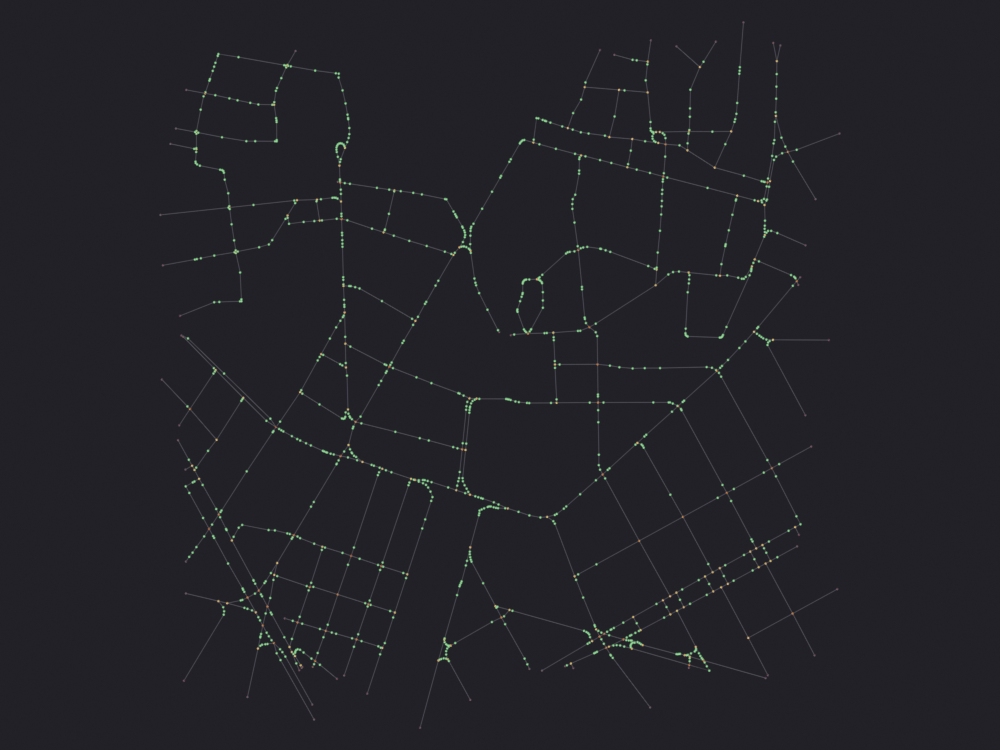

[PASS] 3_simplify_before.png legible — 3.6% ink (healthy range 0.5–60%)


In [22]:
nb.figure(raw, "renders/06_osmnx/3_simplify_before",
          look='ink', color_attribute="node_degree")

  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> node_degree  ·  node_degree -> turbo [log]  [1 … 5] on Point


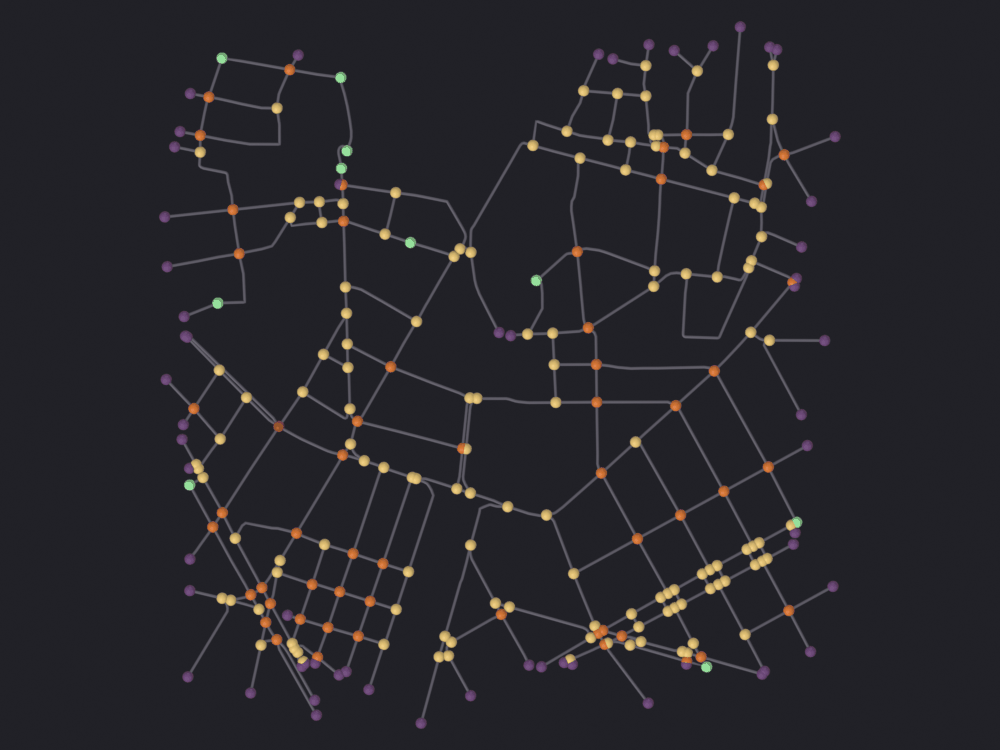

[PASS] 4_simplify_after.png legible — 8.5% ink (healthy range 0.5–60%)


In [23]:
nb.figure(simplified, "renders/06_osmnx/4_simplify_after",
          look='ink', color_attribute="node_degree")

## 4 · Consolidation, and what a tolerance costs

Simplification removes nodes that are not junctions; **consolidation** goes
after the opposite problem, one junction mapped as several nodes. A dual
carriageway crossing another is four nodes in OSM and one intersection on the
ground; a roundabout is a ring of nodes and one intersection.
`osmnx_consolidate` buffers every node by a tolerance in meters, merges what
overlaps, and rebuilds the edges between the survivors.

It enforces two preconditions: the graph must be projected, because a
tolerance in meters is meaningless in degrees
(`graph_operators.py:621-626`), and it must be directed
(`graph_operators.py:628-630`), so this has to happen before any
`to_undirected`.

And one that nothing enforces: once projected the graph is in UTM meters, and
`materialize()`, like every other route into a Blender mesh, reads `x`/`y` as
longitude and latitude. A projected graph silently draws as a mesh tens of
thousands of Blender units across, so a consolidated graph has to go back to
EPSG:4326 before it can be looked at.

In [24]:
sg.graphs.activate(simplified)
print("osmnx_project_graph ->",
      bpy.ops.scigraphs.osmnx_project_graph(crs_preset='AUTO_UTM'))
G_projected = graph_cache.get_osmnx_graph(simplified)
print(f"  crs {simplified.get('osmnx_crs')},  "
      f"projected {simplified.get('osmnx_projected')}")
sample = next(iter(G_projected.nodes(data=True)))[1]
print(f"  a node is now at x={sample['x']:,.1f} y={sample['y']:,.1f} "
      "(meters, not degrees)")

Graph projected to EPSG:32630
Info: Graph projected to EPSG:32630
osmnx_project_graph -> {'FINISHED'}
  crs EPSG:32630,  projected True
  a node is now at x=725,813.2 y=4,371,905.8 (meters, not degrees)


In [25]:
TOLERANCES = (5, 10, 20, 40)

consolidated = {}
print(f"  {'tolerance':>9} {'nodes':>6} {'edges':>6} {'kept':>6} "
      f"{'moved p50':>10} {'moved max':>10}")
for tolerance in TOLERANCES:
    graph_cache.store_osmnx_graph(simplified, G_projected.copy())
    result = bpy.ops.scigraphs.osmnx_consolidate(tolerance=float(tolerance))
    if 'FINISHED' not in result:
        print(f"  {tolerance:>9} {result}")
        continue
    G_c = graph_cache.get_osmnx_graph(simplified)

    shifts, merged = [], {}
    for node, data in G_c.nodes(data=True):
        originals = data.get("osmid_original", data.get("osmid", node))
        if isinstance(originals, str):
            originals = [int(t) for t in originals.strip("[]").split(",")
                         if t.strip().lstrip("-").isdigit()]
        elif not isinstance(originals, (list, tuple, set)):
            originals = [originals]
        merged[node] = len(originals)
        for original in originals:
            if original in G_projected.nodes:
                shifts.append(math.hypot(
                              data["x"] - G_projected.nodes[original]["x"],
                              data["y"] - G_projected.nodes[original]["y"]))
    shifts = np.array(shifts) if shifts else np.zeros(1)
    consolidated[tolerance] = (G_c, merged, shifts)
    print(f"  {tolerance:>9} {G_c.number_of_nodes():>6} "
          f"{G_c.number_of_edges():>6} "
          f"{100 * G_c.number_of_nodes() / G_projected.number_of_nodes():>5.0f}% "
          f"{np.median(shifts):>9.1f} m {shifts.max():>9.1f} m")

graph_cache.store_osmnx_graph(simplified, G_projected)

check("every tolerance consolidated something",
      len(consolidated) == len(TOLERANCES))
check("a node can move further than the tolerance",
      any(shift.max() > tolerance
      for tolerance, (_G, _m, shift) in consolidated.items()),
      "a chain of nodes within the tolerance collapses to one point that "
      "need not be within the tolerance of any of them")

  tolerance  nodes  edges   kept  moved p50  moved max
Intersections consolidated: 254 -> 239 nodes
Info: Consolidated: 254 -> 239 nodes
          5    239    342    94%       0.0 m       5.0 m
Intersections consolidated: 254 -> 205 nodes
Info: Consolidated: 254 -> 205 nodes
         10    205    307    81%       0.0 m      18.8 m
Intersections consolidated: 254 -> 160 nodes
Info: Consolidated: 254 -> 160 nodes
         20    160    245    63%       3.0 m      70.5 m
Intersections consolidated: 254 -> 67 nodes
Info: Consolidated: 254 -> 67 nodes
         40     67    113    26%      65.2 m     302.5 m
[PASS] every tolerance consolidated something
[PASS] a node can move further than the tolerance — a chain of nodes within the tolerance collapses to one point that need not be within the tolerance of any of them


True

Read the last two columns, not the first. The distance a node
moves is the price of the falling node count, and it is not bounded by the
tolerance you set: *t* merges nodes within *t* of **each other**, so a chain
of them (a roundabout, a long staggered junction, a slip road) collapses to a
single point that can sit much further than *t* from any of the originals. At
a large enough tolerance a whole short street becomes a node, and the edge
that was that street goes with it.

There is no universally correct value:

* 10 m is OSMnx's default and about right for an ordinary urban grid;
* a medieval center wants less; the blocks here are short, and 20 m is
  already merging junctions that a pedestrian would tell apart;
* a motorway interchange wants 30 to 50 m, or the slip roads stay as separate
  intersections and every centrality measure is diluted across them;
* quote whatever you choose next to the number, because a node count without
  a tolerance is not reproducible.

Consolidation also throws away node identity: the survivor gets a new integer
id and keeps the originals in `osmid_original`, so anything joined to the
graph by OSM node id has to be re-joined. Notebook 09 hits this when it
attaches points of interest.

### The figure, colored by how many nodes each one swallowed

`node_merged` is 1 where consolidation changed nothing and higher where it
collapsed a cluster. The merges concentrate at a handful of large junctions
while most of the network is untouched, so the long tail is clipped at the
top percentile rather than allowed to flatten everything else into the bottom
stop of the ramp.

In [26]:
CHOSEN_TOLERANCE = 20
G_c, merged, shifts = consolidated[CHOSEN_TOLERANCE]

G_c_wgs = ox.projection.project_graph(G_c, to_crs="epsg:4326")
consolidated_obj = materialize(G_c_wgs, f"Net_consolidated_{CHOSEN_TOLERANCE}m")
written, array = node_attribute(consolidated_obj, merged, "node_merged")

multiple = sum(1 for v in merged.values() if v > 1)
print(f"nodes that swallowed more than one  {multiple} of {len(merged)} "
      f"({100 * multiple / len(merged):.0f} %)")
print(f"largest single merge                {max(merged.values())} nodes into one")
print(f"attribute written on                {written} intersections")
print(f"edges lost to the merge             "
      f"{G_projected.number_of_edges() - G_c.number_of_edges()}")

check("the consolidated graph is back in degrees",
      abs(float(next(iter(G_c_wgs.nodes(data=True)))[1]["x"])) < 180.0,
      "or the mesh would be tens of thousands of Blender units across")


Creating OSMnx graph: 160 nodes, 245 edges...
  Created 160 intersection vertices
  Created 223 street edges in 0.01s
Total OSMnx graph creation time: 0.01s
nodes that swallowed more than one  37 of 160 (23 %)
largest single merge                11 nodes into one
attribute written on                160 intersections
edges lost to the merge             113
[PASS] the consolidated graph is back in degrees — or the mesh would be tens of thousands of Blender units across


True

  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> node_merged  ·  node_merged -> turbo [log]  [1 … 7] on Point


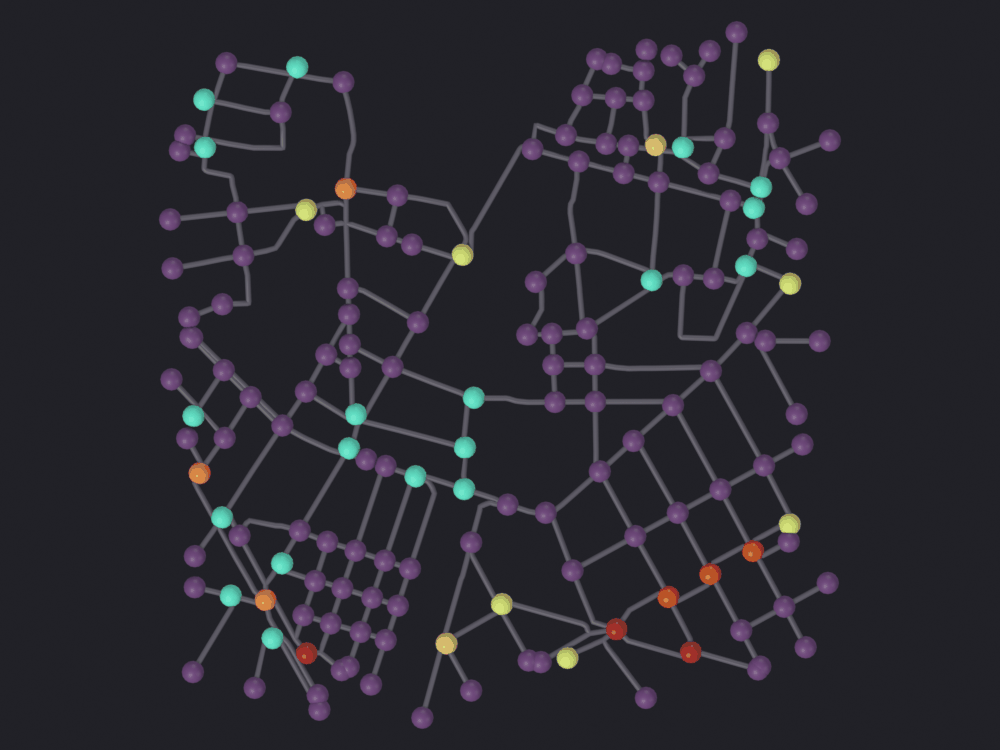

[PASS] 5_consolidated.png legible — 14.7% ink (healthy range 0.5–60%)


In [27]:
nb.figure(consolidated_obj, "renders/06_osmnx/5_consolidated",
          look='ink', color_attribute="node_merged",
          clip_high_pct=98)

## 5 · Direction, and the pieces that are not connected

An OSMnx street graph is a `MultiDiGraph`: a one-way street is one directed
edge, a two-way street is two, and a pair of parallel edges between the same
nodes is how a divided street or a service loop is spelled. Three operators
change that shape, each right for a different question.

In [28]:
walkable = download('POINT', 'walk', retain_all=True)
walkable.name = "Net_walk_all_components"
G_walk = graph_cache.get_osmnx_graph(walkable)
counts(G_walk, "walk, retain_all=True")

sg.graphs.activate(walkable)
print("osmnx_to_undirected ->", bpy.ops.scigraphs.osmnx_to_undirected())
G_undirected = graph_cache.get_osmnx_graph(walkable)
print(f"  {type(G_undirected).__name__:<14} "
      f"{G_undirected.number_of_edges():>5} edges "
      f"({100 * G_undirected.number_of_edges() / G_walk.number_of_edges():.0f} % "
      "of the directed count)")

graph_cache.store_osmnx_graph(walkable, G_walk)
print("osmnx_to_digraph ->", bpy.ops.scigraphs.osmnx_to_digraph())
G_digraph = graph_cache.get_osmnx_graph(walkable)
print(f"  {type(G_digraph).__name__:<14} "
      f"{G_digraph.number_of_edges():>5} edges "
      f"({G_walk.number_of_edges() - G_digraph.number_of_edges()} parallel "
      "edges collapsed, and not recoverable)")
graph_cache.store_osmnx_graph(walkable, G_walk)

check("to_undirected halves a fully bidirectional network",
      G_undirected.number_of_edges() <= G_walk.number_of_edges() / 2 + 1)
check("to_digraph drops the parallel edges",
      G_digraph.number_of_edges() < G_walk.number_of_edges())


  retain_all: True (disconnected components kept)
  Point: (39.46989822387695, -0.37630000710487366), radius: 600m
  Download completed in 1.34s
Total import time: 1.62s
  Nodes: 1,600, Edges: 4,732

Creating OSMnx graph: 1,600 nodes, 4,732 edges...
  Created 1,600 intersection vertices
    Created 1,000 edges...
    Created 2,000 edges...
  Created 2,346 street edges in 0.33s
Total OSMnx graph creation time: 0.34s
Graph saved to ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/39.4699_-0.3763_walk.graphml
Graph cached to: ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/39.4699_-0.3763_walk.graphml
Info: Downloading network from OpenStreetMap (POINT)...
Info: Graph cached as: 39.4699_-0.3763_walk.graphml
Info: Imported: 1600 intersections, 4732 street segments, 148.9 km total
  walk, retain_all=True            1600 nodes   4732 edges    148.9 km
Converted to undirected graph
Info: Converted to undirected graph
osmnx_to_undirected -> {'FINISHED'}
  MultiGraph      

True

* `osmnx_to_undirected` collapses each reciprocal pair into one
  edge. Use it for anything about the *street* rather than travel along it:
  total length, circuity, orientation, street counts. OSMnx converts
  internally before several of its own statistics, and `osmnx_circuity` does
  the same.
* `osmnx_to_digraph` keeps direction but throws away multiplicity, choosing
  the shortest of each parallel bundle. It exists because many NetworkX
  algorithms refuse a multigraph, and it loses edges silently: on a network
  with many divided streets that loss is not small.
* Neither is reversible. `convert.ensure_multidigraph` rebuilds a
  `MultiDiGraph` *shape* afterwards so OSMnx's own helpers keep working, but
  the edges `to_digraph` dropped do not come back.

> `osmnx_to_undirected` sets `obj["is_directed"] = False`, which the
> direction arrows and the directed-analysis panels read, and does not
> rebuild the mesh: the arrows vanish from a network whose drawn geometry has
> not changed.

### Components, and what `retain_all` is for

`retain_all=False`, the default and what every other download here used,
tells OSMnx to keep only the largest weakly connected component. That is
usually right, and it is always a decision. The download above set
`retain_all=True`, so this graph still has everything.

In [29]:
weak = sorted(nx.weakly_connected_components(G_walk), key=len, reverse=True)
strong = sorted(nx.strongly_connected_components(G_walk), key=len, reverse=True)

print(f"nodes                {G_walk.number_of_nodes()}")
print(f"weakly connected     {len(weak)} components, "
      f"sizes {[len(c) for c in weak[:8]]}{' …' if len(weak) > 8 else ''}")
print(f"strongly connected   {len(strong)} components, "
      f"sizes {[len(c) for c in strong[:8]]}{' …' if len(strong) > 8 else ''}")
print(f"the largest weak component holds "
      f"{100 * len(weak[0]) / G_walk.number_of_nodes():.1f} % of the nodes")

sg.graphs.activate(walkable)
print("\nosmnx_largest_component(strongly=False) ->",
      bpy.ops.scigraphs.osmnx_largest_component(strongly=False))
G_weak = graph_cache.get_osmnx_graph(walkable)
counts(G_weak, "largest weak component")

graph_cache.store_osmnx_graph(walkable, G_walk)
print("osmnx_largest_component(strongly=True) ->",
      bpy.ops.scigraphs.osmnx_largest_component(strongly=True))
G_strong = graph_cache.get_osmnx_graph(walkable)
counts(G_strong, "largest strong component")
graph_cache.store_osmnx_graph(walkable, G_walk)

nodes                1600
weakly connected     10 components, sizes [1582, 2, 2, 2, 2, 2, 2, 2] …
strongly connected   10 components, sizes [1582, 2, 2, 2, 2, 2, 2, 2] …
the largest weak component holds 98.9 % of the nodes
Extracted largest component: 1600 -> 1582 nodes
Info: Largest component: 1582 / 1600 nodes

osmnx_largest_component(strongly=False) -> {'FINISHED'}
  largest weak component           1582 nodes   4714 edges    147.6 km
Extracted largest component: 1600 -> 1582 nodes
Info: Largest component: 1582 / 1600 nodes
osmnx_largest_component(strongly=True) -> {'FINISHED'}
  largest strong component         1582 nodes   4714 edges    147.6 km


**When is the largest-component filter the right call?**

* Almost always, for routing: a disconnected fragment is somewhere the router
  cannot reach, and `nx.shortest_path` raises. Notebook 08 depends on this
  having been done.
* Almost always, for centrality: betweenness on a disconnected graph is
  computed per component and is not comparable across them.
* Not, when the fragments are the subject: islands, a pedestrianized precinct
  reachable only on foot, a network deliberately cut by a barrier.
* Not, when the fragments are an artifact of the boundary. Almost all the
  small components here are stubs of exactly two nodes, a street that leaves
  the download box and comes back in: disconnected in this extract, not in
  the world. Download wider and truncate, as section 8 does.

In [30]:
kept = len(weak[0])
print(f"largest component     {kept} nodes")
print(f"discarded             {G_walk.number_of_nodes() - kept} nodes in "
      f"{len(weak) - 1} fragments, sizes "
      f"{sorted({len(c) for c in weak[1:]})}")
print(f"discarded street      {counts(G_walk)[2] - counts(G_weak)[2]:.2f} km "
      f"of {counts(G_walk)[2]:.1f} km "
      f"({100 * (counts(G_walk)[2] - counts(G_weak)[2]) / counts(G_walk)[2]:.1f} %)")

check("the largest component keeps almost everything here",
      kept / G_walk.number_of_nodes() > 0.95,
      f"{100 * kept / G_walk.number_of_nodes():.1f} % of the nodes")

largest component     1582 nodes
discarded             18 nodes in 9 fragments, sizes [2]
discarded street      1.27 km of 148.9 km (0.9 %)
[PASS] the largest component keeps almost everything here — 98.9 % of the nodes


True

### Weak and strong, on a network where they differ

Weak connectivity ignores direction: two nodes are together if you could get
between them disregarding the one-way signs. Strong connectivity respects
them, so the difference is the set of places you can drive into but not out
of, or out of but not into.

On the pedestrian network above the two coincide, because every footway is
two-way, which is a useful check that the `walk` filter did what it claims
and is why that graph could not show this.

In [31]:
G_drive = graph_cache.get_osmnx_graph(networks['drive'])
drive_weak = sorted(nx.weakly_connected_components(G_drive), key=len,
                    reverse=True)
drive_strong = sorted(nx.strongly_connected_components(G_drive), key=len,
                      reverse=True)

print(f"drive network        {G_drive.number_of_nodes()} nodes")
print(f"weakly connected     {len(drive_weak)} component(s), "
      f"sizes {[len(c) for c in drive_weak[:4]]}")
print(f"strongly connected   {len(drive_strong)} components, "
      f"largest {len(drive_strong[0])}, and "
      f"{sum(1 for c in drive_strong if len(c) == 1)} single nodes")
print(f"so {100 * (1 - len(drive_strong[0]) / G_drive.number_of_nodes()):.0f} % "
      "of the intersections are not mutually reachable with the rest")

check("the drive network is weakly but not strongly connected",
      len(drive_weak) == 1 and len(drive_strong) > 1,
      f"one weak component, {len(drive_strong)} strong ones")

drive network        243 nodes
weakly connected     1 component(s), sizes [243]
strongly connected   46 components, largest 198, and 45 single nodes
so 19 % of the intersections are not mutually reachable with the rest
[PASS] the drive network is weakly but not strongly connected — one weak component, 46 strong ones


True

Those single-node strong components are the far end of a
one-way street, a service entrance, an intersection whose only exit was
truncated at the boundary. Nothing reports them, and section 8 shows one of
them silently emptying a catchment.

**`node_balance` is out-degree minus in-degree**: zero where as many ways
lead out as in, negative where a node absorbs more than it emits, positive
where it emits more. On turbo that runs blue through green to red, and the
pattern it draws is the one-way system: pairs of opposite-signed nodes strung
along the streets that only run one way, green where traffic can turn around.

In [32]:
balance = {n: G_drive.out_degree(n) - G_drive.in_degree(n) for n in G_drive}
node_attribute(networks['drive'], balance, "node_balance")

values = np.array(list(balance.values()))
print(f"out-degree minus in-degree: {values.min()} to {values.max()}")
for value in range(int(values.min()), int(values.max()) + 1):
    share = 100 * (values == value).mean()
    print(f"  {value:>+3}  {(values == value).sum():>4} nodes  {share:>5.1f} %")
no_exit = [n for n in G_drive if G_drive.out_degree(n) == 0]
no_entry = [n for n in G_drive if G_drive.in_degree(n) == 0]
print(f"of which no way out at all  {len(no_exit)} nodes")
print(f"          no way in at all  {len(no_entry)} nodes")

check("the balance is not everywhere zero",
      float((values != 0).mean()) > 0.5,
      f"{100 * (values != 0).mean():.0f} % of intersections are asymmetric")

out-degree minus in-degree: -2 to 2
   -2    11 nodes    4.5 %
   -1    77 nodes   31.7 %
   +0    66 nodes   27.2 %
   +1    79 nodes   32.5 %
   +2    10 nodes    4.1 %
of which no way out at all  17 nodes
          no way in at all  15 nodes
[PASS] the balance is not everywhere zero — 73 % of intersections are asymmetric


True

  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> node_balance  ·  node_balance -> turbo [log]  [-2 … 2] on Point


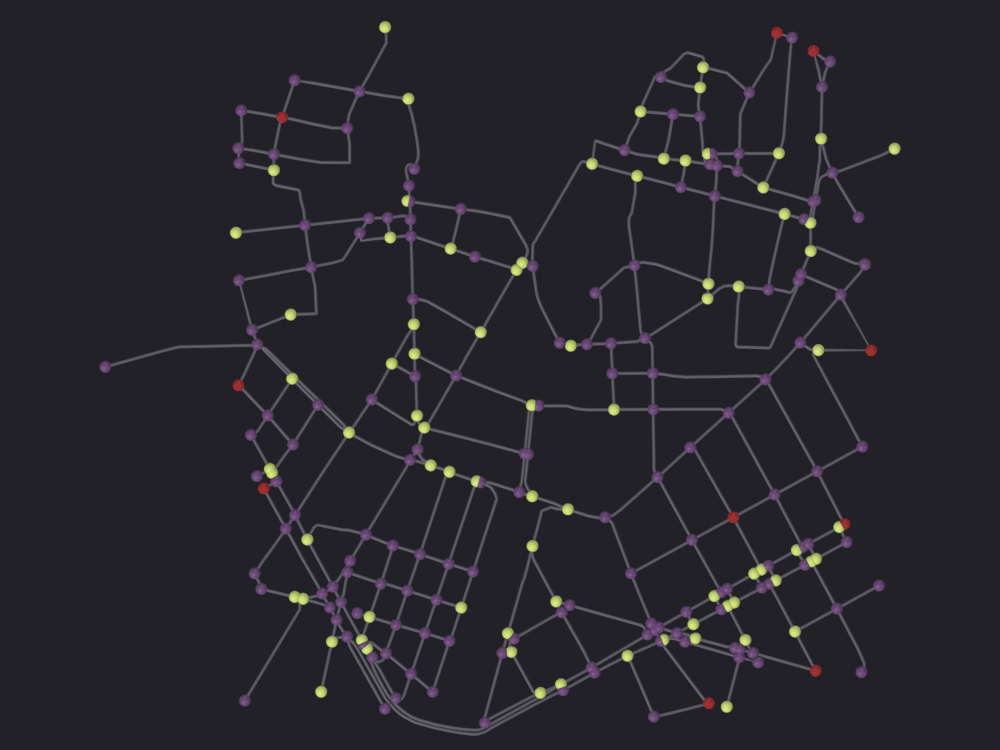

[PASS] 6_direction.png legible — 9.2% ink (healthy range 0.5–60%)


In [33]:
nb.figure(networks['drive'], "renders/06_osmnx/6_direction",
          look='ink', color_attribute="node_balance")

## 6 · The basic statistics, and what they mean here

`osmnx_basic_stats` wraps `ox.basic_stats` and writes each result onto the
object as `osmnx_stat_*`. The densities among them need an area, which the
operator takes from `osmnx_network_area` when it is set and otherwise
estimates as the convex hull of the nodes, through `osmnx_estimate_area`.

The hull is **not** the study area. With `truncate_by_edge=True` the network
reaches past the 600 m disc, so the hull is larger and every density comes
out correspondingly smaller. If the study area is a district boundary or a
census tract, set `osmnx_network_area` by hand first.

In [34]:
stats_obj = materialize(G_point, "Net_drive_stats")
sg.graphs.activate(stats_obj)

props.osmnx_network_area = 0.0
print("osmnx_estimate_area ->", bpy.ops.scigraphs.osmnx_estimate_area())
print(f"  convex hull {props.osmnx_network_area:.3f} km2, against "
      f"{math.pi * (RADIUS_M / 1000) ** 2:.3f} km2 for the requested disc "
      f"({100 * props.osmnx_network_area / (math.pi * (RADIUS_M / 1000) ** 2) - 100:+.0f} %)")

print("osmnx_basic_stats ->", bpy.ops.scigraphs.osmnx_basic_stats())
for key in sorted(k for k in stats_obj.keys() if k.startswith("osmnx_stat_")):
    print(f"  {key[len('osmnx_stat_'):]:<30} {stats_obj[key]}")

check("the statistics landed on the object",
      bool(stats_obj.get("osmnx_stats_calculated")))


Creating OSMnx graph: 243 nodes, 375 edges...
  Created 243 intersection vertices
  Created 361 street edges in 0.01s
Total OSMnx graph creation time: 0.01s
Estimated network area: 2.02 km2
Info: Estimated network area: 2.02 km2
osmnx_estimate_area -> {'FINISHED'}
  convex hull 2.021 km2, against 1.131 km2 for the requested disc (+79 %)
Basic stats calculated: 243 nodes, 375 edges
Info: Nodes: 243, Edges: 375, Length: 31.8 km
osmnx_basic_stats -> {'FINISHED'}
  avg_degree                     3.09
  avg_edge_length_m              84.8
  circuity_avg                   1.041
  dead_end_count                 0
  edge_density_per_km2           15722.38
  intersection_count             239
  n_edges                        375
  n_nodes                        243
  node_density_per_km2           120.21
  street_density_km_per_km2      15339.75
  street_segments_per_node       3.26
  total_length_km                31.78
[PASS] the statistics landed on the object


True

What the interesting ones mean for a street network:

* `street_segments_per_node`: the mean number of physical streets at a
  junction, computed on the *undirected* graph, so it describes the layout
  and not the one-way system. Around 3 is normal urban, mostly T-junctions
  with some crossroads; below 2.5 is cul-de-sac suburbia; above 3.5 a dense
  grid.
* `intersection_count` and `dead_end_count` split the nodes into junctions
  and stubs, and are meaningful only on a *simplified* graph: on a raw one
  nearly every node is a degree-2 non-junction.
* `circuity_avg`: the mean ratio of edge length to the straight-line distance
  between its endpoints. 1.0 is perfectly straight segments; a few percent
  above is a mostly-rectilinear old town. It is a shape statistic and **not**
  a detour factor: a perfect grid has circuity 1.0 and still makes you walk
  1.4 times the crow-flies distance.
* `avg_edge_length_m`: the block size, and the number most sensitive to
  everything above. Simplification multiplies it several times over,
  consolidation raises it again.

> **Two of the density labels are wrong, by a factor of a thousand.**
> `ox.basic_stats` returns `edge_density_km` and `street_density_km` in
> **meters of network per square kilometer**. `SciGraphs/core/osmnx/stats.py`
> (lines 38-40) copies them into `edge_density_per_km2` and
> `street_density_km_per_km2`, whose names promise a count of edges per km²
> and kilometers per km². Divide by 1000 for the figure street-network papers
> quote. `node_density_per_km2` is what its name says.

The two are measured on different graphs: `edge_density` counts the
**directed** edges, `street_density` the **undirected** streets. Their ratio
measures how one-way a network is: 2.0 for a fully two-way street system,
barely above 1 for a medieval center where almost everything runs one way.

In [35]:
area_km2 = float(props.osmnx_network_area)
edge_density = float(stats_obj.get("osmnx_stat_edge_density_per_km2", 0.0))
street_density = float(stats_obj.get("osmnx_stat_street_density_km_per_km2", 0.0))
total_km = float(stats_obj.get("osmnx_stat_total_length_km", 0.0))

print(f"edge_density_per_km2, as reported    {edge_density:>12,.0f}")
print(f"total edge length / area             "
      f"{1000 * total_km / area_km2:>12,.0f}   m per km2")
print(f"street_density_km_per_km2            {street_density:>12,.0f}")
print(f"the figure a paper would quote       "
      f"{street_density / 1000:>12,.1f}   km of street per km2")
print(f"directed / undirected length         "
      f"{edge_density / street_density:>12,.2f}   "
      f"(2.0 would be an entirely two-way network)")

check("the density labeled km/km2 is really m/km2",
      abs(edge_density - 1000 * total_km / area_km2)
      < 0.01 * edge_density,
      "a thousand times the number the name promises")

edge_density_per_km2, as reported          15,722
total edge length / area                   15,721   m per km2
street_density_km_per_km2                  15,340
the figure a paper would quote               15.3   km of street per km2
directed / undirected length                 1.02   (2.0 would be an entirely two-way network)
[PASS] the density labeled km/km2 is really m/km2 — a thousand times the number the name promises


True

## 7 · The round trip, and whether it is lossless

`graph_to_gdfs` turns the graph into two GeoDataFrames, nodes indexed by
`osmid` and edges by `(u, v, key)`, and `gdfs_to_graph` turns them back. That
pair is the seam between OSMnx and every other geospatial tool. Three
versions of the same trip below, and they do not all pass.

In [36]:
gdf_nodes, gdf_edges = convert.graph_to_gdfs(G_point)

print(f"nodes {len(gdf_nodes):>5}  index {gdf_nodes.index.names}")
print(f"      {list(gdf_nodes.columns)}")
print(f"edges {len(gdf_edges):>5}  index {gdf_edges.index.names}")
print(f"      {list(gdf_edges.columns)}")

nodes   243  index ['osmid']
      ['y', 'x', 'street_count', 'highway', 'geometry']
edges   375  index ['u', 'v', 'key']
      ['osmid', 'highway', 'lanes', 'maxspeed', 'name', 'oneway', 'reversed', 'length', 'geometry', 'width', 'tunnel', 'access', 'junction']


### In memory

The strict test: same node set, same `(u, v, key)` triples, and the same
attribute names on both sides.

In [37]:
G_back = convert.graph_from_gdfs(gdf_nodes, gdf_edges)


def edge_attrs(G):
    keys = set()
    for *_ids, data in G.edges(keys=True, data=True):
        keys |= set(data)
    return keys


def node_attrs(G):
    keys = set()
    for _n, data in G.nodes(data=True):
        keys |= set(data)
    return keys


print(f"nodes           {G_point.number_of_nodes()} -> {G_back.number_of_nodes()}")
print(f"edges           {G_point.number_of_edges()} -> {G_back.number_of_edges()}")
print(f"node ids equal  {set(G_point.nodes) == set(G_back.nodes)}")
print(f"edge keys equal "
      f"{set(G_point.edges(keys=True)) == set(G_back.edges(keys=True))}")
print(f"node attributes {sorted(node_attrs(G_point))}")
print(f"          after {sorted(node_attrs(G_back))}")
print(f"edge attributes {sorted(edge_attrs(G_point))}")
print(f"          after {sorted(edge_attrs(G_back))}")

lost = set(G_point.graph) - set(G_back.graph)
print(f"\ngraph-level metadata before {sorted(G_point.graph)}")
print(f"                      after {sorted(G_back.graph)}")
print(f"                       lost {sorted(lost)}")

check("the node and edge sets survive the round trip",
      set(G_point.nodes) == set(G_back.nodes)
      and set(G_point.edges(keys=True)) == set(G_back.edges(keys=True)))
check("every node and edge attribute survives",
      node_attrs(G_point) == node_attrs(G_back)
      and edge_attrs(G_point) == edge_attrs(G_back))
check("the graph-level metadata does not", bool(lost),
      f"{sorted(lost)} are dropped; `graph_from_gdfs` keeps only the CRS "
      "unless `graph_attrs=` is passed")

nodes           243 -> 243
edges           375 -> 375
node ids equal  True
edge keys equal True
node attributes ['highway', 'street_count', 'x', 'y']
          after ['highway', 'street_count', 'x', 'y']
edge attributes ['access', 'geometry', 'highway', 'junction', 'lanes', 'length', 'maxspeed', 'name', 'oneway', 'osmid', 'reversed', 'tunnel', 'width']
          after ['access', 'geometry', 'highway', 'junction', 'lanes', 'length', 'maxspeed', 'name', 'oneway', 'osmid', 'reversed', 'tunnel', 'width']

graph-level metadata before ['created_date', 'created_with', 'crs', 'simplified']
                      after ['crs']
                       lost ['created_date', 'created_with', 'simplified']
[PASS] the node and edge sets survive the round trip
[PASS] every node and edge attribute survives
[PASS] the graph-level metadata does not — ['created_date', 'created_with', 'simplified'] are dropped; `graph_from_gdfs` keeps only the CRS unless `graph_attrs=` is passed


True

Node and edge identity, geometry and every per-feature
attribute come back exactly. What is dropped is `G.graph`, and the entry that
matters there is **`simplified`**, the flag `osmnx_simplify` checks before
refusing to run twice (`graph_operators.py:555`). A graph that has been
through the GeoDataFrame round trip can be simplified again; OSMnx will
oblige, and the result is wrong in ways that are hard to see. `created_date`
and `created_with` go with it, which is provenance rather than data, and
provenance has its own notebook (**07**).

### Through files, via the operators

`osmnx_graph_to_gdfs` writes two GeoJSONs and `osmnx_gdfs_to_graph` reads
two: the file version of the pair above, and the obvious way to get a network
out to QGIS and back. **They do not compose.**

In [38]:
out_dir = nb.out("10_osmnx")
out_dir.mkdir(parents=True, exist_ok=True)
base = out_dir / "roundtrip"

sg.graphs.activate(networks['drive'])
print("osmnx_graph_to_gdfs ->",
      bpy.ops.scigraphs.osmnx_graph_to_gdfs(filepath=str(base) + ".geojson"))
for path in sorted(out_dir.glob("roundtrip_*.geojson")):
    print(f"  {path.name:<26} {path.stat().st_size / 1e3:>8.1f} kB")

file_nodes = gpd.read_file(base.with_name("roundtrip_nodes.geojson"))
file_edges = gpd.read_file(base.with_name("roundtrip_edges.geojson"))
print(f"\nread back: nodes index {file_nodes.index.names}, "
      f"columns {list(file_nodes.columns)[:5]} …")
print(f"           edges index {file_edges.index.names}, "
      f"columns {list(file_edges.columns)[:5]} …")

failure = None
try:
    convert.graph_from_gdfs(file_nodes, file_edges)
except Exception as exc:                    # noqa: BLE001 - this is the point
    failure = f"{type(exc).__name__}: {exc}"
print(f"\ngraph_from_gdfs on what was just written -> {failure or 'OK'}")

check("the operator pair cannot read its own output", failure is not None,
      "GeoJSON has no MultiIndex, so u, v, key and osmid come back as "
      "plain columns and graph_from_gdfs rejects them")

Info: GeoDataFrames saved: 243 nodes, 375 edges
osmnx_graph_to_gdfs -> {'FINISHED'}
  roundtrip_edges.geojson       200.8 kB
  roundtrip_nodes.geojson        50.3 kB

read back: nodes index [None], columns ['osmid', 'y', 'x', 'street_count', 'highway'] …
           edges index [None], columns ['u', 'v', 'key', 'osmid', 'highway'] …

graph_from_gdfs on what was just written -> IndexError: Too many levels: Index has only 1 level, not 2
[PASS] the operator pair cannot read its own output — GeoJSON has no MultiIndex, so u, v, key and osmid come back as plain columns and graph_from_gdfs rejects them


True

> **Defect.** `SCIGRAPHS_OT_GraphToGDFs` calls
> `to_file(..., driver='GeoJSON')` (`graph_operators.py:1065-1066`), and
> GeoJSON has no concept of an index, so the MultiIndex is flattened into
> ordinary columns. `SCIGRAPHS_OT_GDFsToGraph` then calls `gpd.read_file` and
> hands the result straight to `graph_from_gdfs`
> (`graph_operators.py:1108-1111`), which requires `osmid` as the node index
> and `(u, v, key)` as a three-level edge MultiIndex. The result is
> `IndexError: Too many levels`.

Restoring the index is one line each way, and it is the first of three
layers. The second: GDAL types a column by the widest thing in it, and a
simplified graph has a handful of edges whose `highway` or `name` is a *list*
of the ways that were merged, so the whole column is written as a string
list. The arrays that reading produces are not lists either, and
`graph_from_gdfs` rejects them.

In [39]:
indexed_nodes = file_nodes.set_index("osmid")
indexed_edges = file_edges.set_index(["u", "v", "key"])

second = None
try:
    convert.graph_from_gdfs(indexed_nodes, indexed_edges)
except Exception as exc:                    # noqa: BLE001 - also the point
    second = f"{type(exc).__name__}: {exc}"
print(f"with the index restored -> {second or 'OK'}")


def delist(gdf):
    """Turn the arrays GeoJSON reading produces back into plain lists."""
    frame = gdf.copy()
    for column in frame.columns:
        if column == frame.geometry.name:
            continue
        if frame[column].map(lambda v: isinstance(v, np.ndarray)).any():
            frame[column] = frame[column].map(
                lambda v: list(v) if isinstance(v, np.ndarray) else v)
    return frame


G_from_file = convert.graph_from_gdfs(delist(indexed_nodes),
                                      delist(indexed_edges))
print(f"and with the arrays unpacked -> {G_from_file.number_of_nodes()} nodes, "
      f"{G_from_file.number_of_edges()} edges")
print(f"node ids equal  {set(G_from_file.nodes) == set(G_point.nodes)}")
print(f"edge keys equal "
      f"{set(G_from_file.edges(keys=True)) == set(G_point.edges(keys=True))}")

check("the topology survives the file round trip once both are fixed",
      set(G_from_file.nodes) == set(G_point.nodes)
      and set(G_from_file.edges(keys=True))
      == set(G_point.edges(keys=True)))

with the index restored -> ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()
and with the arrays unpacked -> 243 nodes, 375 edges
node ids equal  True
edge keys equal True
[PASS] the topology survives the file round trip once both are fixed


True

The third layer is the one no amount of re-indexing gets back:
**the values themselves changed type.** An edge whose `highway` was the
string `"secondary"` now has the list `["secondary"]`, because one edge
elsewhere in the column needed a list and GeoJSON cannot say that only some
rows are lists. Anything comparing `data["highway"] == "secondary"`, which is
most code that touches OSM tags, silently stops matching.

In [40]:
def kinds(graph, attribute):
    counts_ = {"scalar": 0, "list": 0, "missing": 0}
    for *_ids, data in graph.edges(keys=True, data=True):
        value = data.get(attribute)
        if value is None:
            counts_["missing"] += 1
        elif isinstance(value, (list, tuple, np.ndarray)):
            counts_["list"] += 1
        else:
            counts_["scalar"] += 1
    return counts_


for attribute in ("highway", "name", "osmid"):
    before, after = kinds(G_point, attribute), kinds(G_from_file, attribute)
    print(f"  {attribute:<8} before {before}")
    print(f"  {'':<8} after  {after}")

check("scalar tags come back as one-element lists",
      kinds(G_from_file, "highway")["scalar"]
      < kinds(G_point, "highway")["scalar"],
      "GeoJSON promotes the whole column to a list type")

  highway  before {'scalar': 372, 'list': 3, 'missing': 0}
           after  {'scalar': 0, 'list': 375, 'missing': 0}
  name     before {'scalar': 337, 'list': 35, 'missing': 3}
           after  {'scalar': 0, 'list': 372, 'missing': 3}
  osmid    before {'scalar': 290, 'list': 85, 'missing': 0}
           after  {'scalar': 290, 'list': 85, 'missing': 0}
[PASS] scalar tags come back as one-element lists — GeoJSON promotes the whole column to a list type


True

So the GeoJSON pair is for *looking at the network in QGIS*,
not for moving a graph. GeoPackage, which `sg.graphs.save_gdf` writes and section
10 uses, keeps the column types and is the right choice for the geometry. For
the **graph**, the format that survives all three layers is GraphML.

### GraphML, which is the format that keeps everything

`osmnx_save_graphml` / `osmnx_load_graphml` is the pair for a graph that has
to survive a restart. GraphML is what OSMnx itself uses for persistence and
keeps the graph-level metadata the GeoDataFrame trip drops.
`osmnx_load_graphml` also builds the Blender object, which makes it the one
operator route that materializes a graph from outside the importer.

In [41]:
graphml_path = out_dir / "ciutat_vella_drive.graphml"
sg.graphs.activate(networks['drive'])
print("osmnx_save_graphml ->",
      bpy.ops.scigraphs.osmnx_save_graphml(filepath=str(graphml_path)))
print(f"  {graphml_path.name}  {graphml_path.stat().st_size / 1e3:.0f} kB")

print("osmnx_load_graphml ->",
      bpy.ops.scigraphs.osmnx_load_graphml(filepath=str(graphml_path)))
reloaded = bpy.context.active_object
reloaded.name = "Net_drive_from_graphml"
G_graphml = graph_cache.get_osmnx_graph(reloaded)

print(f"  {G_graphml.number_of_nodes()} nodes, {G_graphml.number_of_edges()} edges")
print(f"  graph metadata {sorted(G_graphml.graph)}")
print(f"  simplified flag {G_graphml.graph.get('simplified')!r}")

check("GraphML keeps the topology",
      set(G_graphml.nodes) == set(G_point.nodes)
      and G_graphml.number_of_edges() == G_point.number_of_edges())
check("GraphML keeps the `simplified` flag the GeoDataFrame trip lost",
      bool(G_graphml.graph.get("simplified")))

Graph saved to notebooks/out/10_osmnx/ciutat_vella_drive.graphml
Info: Graph saved to notebooks/out/10_osmnx/ciutat_vella_drive.graphml
osmnx_save_graphml -> {'FINISHED'}
  ciutat_vella_drive.graphml  227 kB
Graph loaded from notebooks/out/10_osmnx/ciutat_vella_drive.graphml

Creating OSMnx graph: 243 nodes, 375 edges...
  Created 243 intersection vertices
  Created 361 street edges in 0.01s
Total OSMnx graph creation time: 0.01s
Info: Loaded graph from ciutat_vella_drive.graphml: 243 nodes, 375 edges
osmnx_load_graphml -> {'FINISHED'}
  243 nodes, 375 edges
  graph metadata ['created_date', 'created_with', 'crs', 'simplified']
  simplified flag True
[PASS] GraphML keeps the topology
[PASS] GraphML keeps the `simplified` flag the GeoDataFrame trip lost


True

## 8 · Truncation: keeping less than you downloaded

Three operators cut an existing graph down rather than asking for less in the
first place. The honest way to get a clean 500 m study area is to download
700 m and truncate: the boundary artifacts, the stubs that made up almost
every disconnected component in section 5, then fall outside the area you
report on.

* `osmnx_truncate_bbox`: a rectangle, read off the `osmnx_bbox_*` properties.
* `osmnx_truncate_distance`: network distance from the node nearest a point,
  which is how a catchment is thought about.
* `osmnx_truncate_polygon`: an arbitrary boundary, taken from a selected
  Blender mesh whose vertex coordinates are read as lon/lat, exactly as the
  `POLYGON` download does.

In [42]:
truncation = materialize(G_point, "Net_drive_truncation")
G_full = graph_cache.get_osmnx_graph(truncation)
sg.graphs.activate(truncation)

props.osmnx_truncate_by_edge = True
props.osmnx_bbox_north, props.osmnx_bbox_south = north, south
props.osmnx_bbox_east, props.osmnx_bbox_west = east, west
print("osmnx_truncate_bbox ->", bpy.ops.scigraphs.osmnx_truncate_bbox())
G_bbox = graph_cache.get_osmnx_graph(truncation)
counts(G_full, "before")
counts(G_bbox, "after osmnx_truncate_bbox")


Creating OSMnx graph: 243 nodes, 375 edges...
  Created 243 intersection vertices
  Created 361 street edges in 0.01s
Total OSMnx graph creation time: 0.01s
Graph truncated by bbox: 243 -> 2 nodes
Info: Truncated: 243 -> 2 nodes
osmnx_truncate_bbox -> {'FINISHED'}
  before                            243 nodes    375 edges     31.8 km
  after osmnx_truncate_bbox           2 nodes      1 edges      0.1 km


(2, 1, 0.14732225703394888)

> **Defect.** `truncate_graph_bbox` builds its tuple as
> `(north, south, east, west)` and passes it to
> `ox.truncate.truncate_graph_bbox` under the keyword `bbox`
> (`graph_operators.py:696-701`, `core/osmnx/truncate.py:24-35`). OSMnx 2.x
> reads that argument as `(left, bottom, right, top)`. So the northern
> *latitude* is used as a longitude and the western *longitude* as a
> latitude, and the rectangle actually applied has nothing to do with the one
> in the panel. `_osmnx_graph_from_bbox` in the importer gets this right for
> downloads by switching on `ox.__version__`; the truncation path was never
> given the same treatment.

In [43]:
asked = (props.osmnx_bbox_north, props.osmnx_bbox_south,
         props.osmnx_bbox_east, props.osmnx_bbox_west)
print(f"the panel says      N={asked[0]:.5f}  S={asked[1]:.5f}  "
      f"E={asked[2]:.5f}  W={asked[3]:.5f}")
print(f"OSMnx 2.x reads it  left={asked[0]:.5f}  bottom={asked[1]:.5f}  "
      f"right={asked[2]:.5f}  top={asked[3]:.5f}")
print(f"so the rectangle applied spans longitude "
      f"{min(asked[0], asked[2]):.2f} to {max(asked[0], asked[2]):.2f} and "
      f"latitude {min(asked[1], asked[3]):.2f} to {max(asked[1], asked[3]):.2f}")
print(f"the box that was meant is {2 * RADIUS_M} m square at "
      f"({CENTER[0]:.4f}, {CENTER[1]:.4f})")

G_correct = ox.truncate.truncate_graph_bbox(
    G_full.copy(), (west, south, east, north), truncate_by_edge=True)
counts(G_correct, "with the box in OSMnx 2.x order")

check("the mis-ordered box destroys the graph",
      G_bbox.number_of_nodes() < 0.05 * G_full.number_of_nodes(),
      f"{G_bbox.number_of_nodes()} of {G_full.number_of_nodes()} nodes "
      "survive a rectangle forty degrees across whose northern edge lands "
      "a few hundred meters south of the network")
check("the same call with the box in OSMnx order keeps the network",
      G_correct.number_of_nodes() > 0.9 * G_full.number_of_nodes(),
      f"{G_correct.number_of_nodes()} of {G_full.number_of_nodes()} nodes")

the panel says      N=39.47530  S=39.46450  E=-0.36931  W=-0.38329
OSMnx 2.x reads it  left=39.47530  bottom=39.46450  right=-0.36931  top=-0.38329
so the rectangle applied spans longitude -0.37 to 39.48 and latitude -0.38 to 39.46
the box that was meant is 1200 m square at (39.4699, -0.3763)
  with the box in OSMnx 2.x order    242 nodes    373 edges     31.6 km
[PASS] the mis-ordered box destroys the graph — 2 of 243 nodes survive a rectangle forty degrees across whose northern edge lands a few hundred meters south of the network
[PASS] the same call with the box in OSMnx order keeps the network — 242 of 243 nodes


True

### Truncating by network distance

`osmnx_truncate_distance` finds the node nearest a point and keeps everything
within a distance *along the streets* of it, rather than through the walls.
This is the operator for a catchment.

It has a failure mode that reports success. The distance is measured
**outward** along a directed graph, so if the node nearest your point has no
outgoing edges (the far end of a one-way cul-de-sac, of which a drive network
has plenty) nothing is reachable from it and the truncation returns that one
node, with `FINISHED` and a node count in the status bar and nothing else.

In [44]:
graph_cache.store_osmnx_graph(truncation, G_full)
CATCHMENT_M = 400
print("osmnx_truncate_distance on the drive network ->",
      bpy.ops.scigraphs.osmnx_truncate_distance(
      center_lat=CENTER[0], center_lon=CENTER[1],
      distance=float(CATCHMENT_M)))
G_dead = graph_cache.get_osmnx_graph(truncation)
counts(G_full, "before")
counts(G_dead, f"within {CATCHMENT_M} m of the center")

nearest = ox.distance.nearest_nodes(G_full, X=CENTER[1], Y=CENTER[0])
sinks = [n for n in G_full.nodes if G_full.out_degree(n) == 0]
print(f"\nthe node nearest the center is {nearest}: "
      f"in-degree {G_full.in_degree(nearest)}, "
      f"out-degree {G_full.out_degree(nearest)}")
print(f"nodes with no outgoing edge at all: {len(sinks)} of "
      f"{G_full.number_of_nodes()}")

graph_cache.store_osmnx_graph(truncation, G_full)

check("a catchment from a sink is one node, reported as success",
      G_dead.number_of_nodes() <= 1 and G_dead.number_of_edges() == 0,
      "check the out-degree of the node you are measuring from, or "
      "convert to undirected first")

Nearest node to (39.46989822387695, -0.37630000710487366): 5902824970
Graph truncated by distance: 243 -> 1 nodes
Info: Truncated: 243 -> 1 nodes (0.4km radius)
osmnx_truncate_distance on the drive network -> {'FINISHED'}
  before                            243 nodes    375 edges     31.8 km
  within 400 m of the center          1 nodes      0 edges      0.0 km

the node nearest the center is 5902824970: in-degree 1, out-degree 0
nodes with no outgoing edge at all: 17 of 243
[PASS] a catchment from a sink is one node, reported as success — check the out-degree of the node you are measuring from, or convert to undirected first


True

### The catchment that means something

A pedestrian catchment on the pedestrian network. The `walk` graph is dense
enough that 400 m of walking reaches a few hundred intersections, and it has
no sinks worth speaking of because every footway is two-way.

400 m along the streets is not 400 m across the ground: the furthest node the
catchment keeps is well inside a 400 m circle, and the boundary is ragged,
bulging along the through streets and pulling in where the blocks force a
detour. That is the reason to compute a catchment rather than draw a circle.

In [45]:
walk_source = materialize(graph_cache.get_osmnx_graph(networks['walk']),
                          "Net_walk_truncation")
G_walk_full = graph_cache.get_osmnx_graph(walk_source)
sg.graphs.activate(walk_source)
print("osmnx_truncate_distance on the walk network ->",
      bpy.ops.scigraphs.osmnx_truncate_distance(
      center_lat=CENTER[0], center_lon=CENTER[1],
      distance=float(CATCHMENT_M)))
G_near = graph_cache.get_osmnx_graph(walk_source)
counts(G_walk_full, "before")
counts(G_near, f"within {CATCHMENT_M} m along the network")

straight_line = {
    n: math.hypot((d["y"] - CENTER[0]) * meters_per_degree,
                  (d["x"] - CENTER[1]) * meters_per_degree
                  * math.cos(math.radians(CENTER[0])))
    for n, d in G_near.nodes(data=True)}
values = np.array(list(straight_line.values()))
print(f"  straight-line distance of the nodes kept: "
      f"median {np.median(values):.0f} m, max {values.max():.0f} m")
print(f"  a {CATCHMENT_M} m circle would have reached {CATCHMENT_M} m in every "
      "direction")
print(f"  so the catchment covers about "
      f"{100 * (values.max() / CATCHMENT_M) ** 2:.0f} % of the circle's area "
      "at best, and less in practice")

catchment = materialize(G_near, f"Net_catchment_{CATCHMENT_M}m")
node_attribute(catchment, straight_line, "node_crow_m")
graph_cache.store_osmnx_graph(walk_source, G_walk_full)

check("the catchment is a subset of the network",
      set(G_near.nodes) <= set(G_walk_full.nodes))
check("network distance is not straight-line distance",
      values.max() < CATCHMENT_M,
      f"the furthest node kept is {values.max():.0f} m away in a straight "
      f"line, having cost {CATCHMENT_M} m of walking")


Creating OSMnx graph: 1,582 nodes, 4,714 edges...
  Created 1,582 intersection vertices
    Created 1,000 edges...
    Created 2,000 edges...
  Created 2,337 street edges in 0.34s
Total OSMnx graph creation time: 0.34s
Nearest node to (39.46989822387695, -0.37630000710487366): 5902851069
Graph truncated by distance: 1582 -> 332 nodes
Info: Truncated: 1582 -> 332 nodes (0.4km radius)
osmnx_truncate_distance on the walk network -> {'FINISHED'}
  before                           1582 nodes   4714 edges    147.6 km
  within 400 m along the network    332 nodes    976 edges     28.4 km
  straight-line distance of the nodes kept: median 212 m, max 364 m
  a 400 m circle would have reached 400 m in every direction
  so the catchment covers about 83 % of the circle's area at best, and less in practice

Creating OSMnx graph: 332 nodes, 976 edges...
  Created 332 intersection vertices
  Created 483 street edges in 0.02s
Total OSMnx graph creation time: 0.02s
[PASS] the catchment is a subset of 

True

  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> node_crow_m  ·  node_crow_m -> turbo [log]  [24.95 … 364.3] on Point


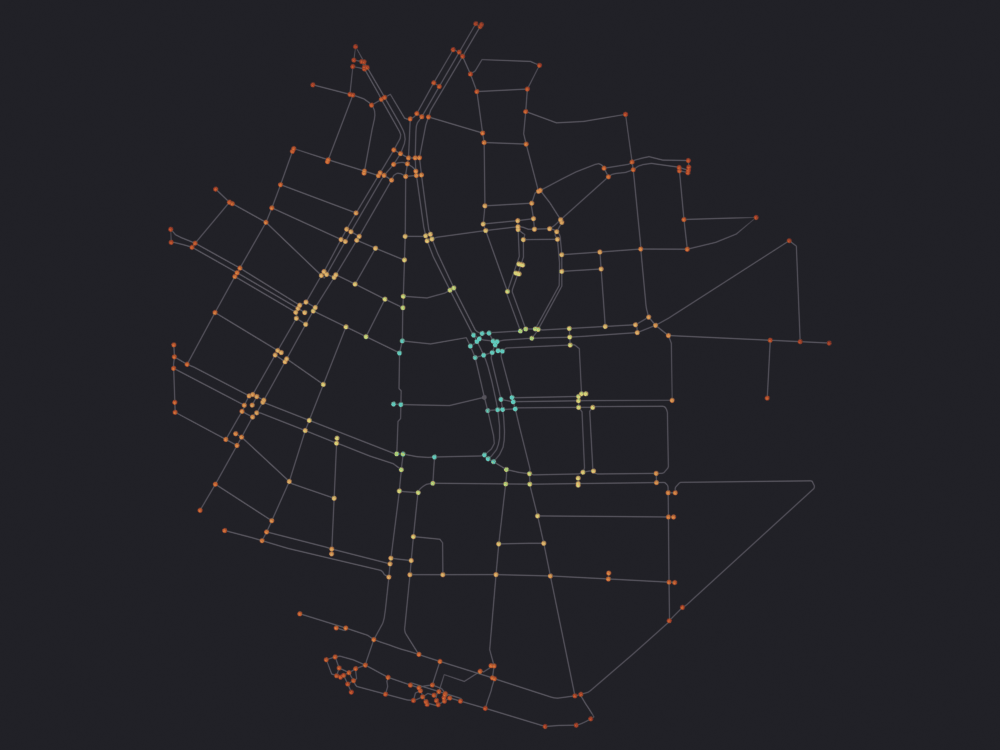

[PASS] 7_catchment.png legible — 4.4% ink (healthy range 0.5–60%)


In [46]:
nb.figure(catchment, "renders/06_osmnx/7_catchment",
          look='ink', color_attribute="node_crow_m")

## 9 · Two caches, and neither of them is the other

| | **OSMnx response cache** | **SciGraphs GraphML cache** |
|---|---|---|
| Holds | the raw Overpass JSON | the parsed `MultiDiGraph` |
| Keyed on | a hash of the query string | `<query_name>_<network_type>.graphml` |
| Written by | OSMnx, on every request | `import_osm_graph`, automatically |
| Read by | OSMnx, before every request | `get_osmnx_graph`, when memory is empty |
| Saves | **the network round trip** | the parse, and the graph after a restart |
| Set by | `ox.settings.cache_folder`, via `nb.osmnx()` | the `osmnx_cache_directory` preference |

The first keeps this notebook runnable. The second makes a `.blend`
re-openable: `restore_all_graphs_from_cache` runs on file load and refills
the in-memory dict for every OSMnx object in the scene, so the analysis
operators work again without a download.

In [47]:
print("OSMnx response cache")
print(f"  {nb.rel(ox.settings.cache_folder)}")
responses = sorted(CACHE_DIR.glob("*.json"))
print(f"  {len(responses)} responses, "
      f"{sum(p.stat().st_size for p in responses) / 1e6:.1f} MB")

print("\nSciGraphs GraphML cache")
print(f"  {nb.rel(sg_cache.get_cache_directory())}")
entries = sg_cache.list_cached_graphs()
print(f"  {len(entries)} graphs, {sum(e[2] for e in entries):.1f} MB")
for filename, _path, size_mb, _mtime in entries[:6]:
    print(f"    {filename:<48} {size_mb:>6.2f} MB")
if len(entries) > 6:
    print(f"    … and {len(entries) - 6} more")

# `osmnx_view_cached_graphs` is this listing as a dialog, invoke-only, so there
# is nothing to run headless. `osmnx_clear_cache` empties the directory.
print("\ncache operators:",
      sorted(name for name in dir(bpy.ops.scigraphs)
      if "cache" in name and name.startswith("osmnx")))

OSMnx response cache
  notebooks/data/cache/osmnx
  47 responses, 81.5 MB

SciGraphs GraphML cache
  ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache
  45 graphs, 126.8 MB
    39.4699_-0.3763_walk.graphml                       1.93 MB
    39.4699_-0.3763_drive.graphml                      0.63 MB
    39.4699_-0.3763_all.graphml                        2.04 MB
    39.4699_-0.3763_bike.graphml                       0.77 MB
    polygon_AOI_CiutatVella_drive.graphml              0.18 MB
    bbox_39.48_39.46_drive.graphml                     0.22 MB
    … and 39 more

cache operators: ['osmnx_clear_cache', 'osmnx_delete_cached_graph', 'osmnx_load_from_cache', 'osmnx_open_cache_directory', 'osmnx_save_to_cache', 'osmnx_view_cached_graphs']


### The GraphML filename is a lossy key, and it collides in silence

The cache entry is named from `osmnx_query_name` and `osmnx_network_type` and
nothing else (`SciGraphs/core/osmnx/cache.py:78-105`). For a `POINT` download
`osmnx_query_name` is `f"{lat:.4f}_{lon:.4f}"` (`data_operators.py:659`), so
**the radius is not in the key**, and neither are `simplify`, `retain_all`,
`truncate_by_edge` or any `custom_filter`. Every `drive` download this
notebook made at this center wrote to the same file: the 600 m disc, the
unsimplified version, the `retain_all=True` version. Each overwrote the last,
and if `get_osmnx_graph` ever falls through to disk it gets whichever ran
most recently. A `BBOX` download is keyed on
`f"bbox_{north:.2f}_{south:.2f}"` (`data_operators.py:661`), dropping east
and west entirely: two boxes at the same latitudes are one cache entry.

The in-memory cache is keyed by a UUID per object, so the collision bites
only after a restart, or on the `load_graph_from_cache` fallback.

In [48]:
print(f"query_name for the POINT download  {net.get('osmnx_query_name')!r}")
print(f"cache filename                     "
      f"{sg_cache.generate_cache_filename(net)}")
print(f"the radius that produced it        {RADIUS_M} m, not in the name")

collisions = {}
for obj in bpy.data.objects:
    if obj.get("is_osmnx"):
        collisions.setdefault(
            sg_cache.generate_cache_filename(obj), []).append(obj.name)

print("\nobjects in this scene that share a cache filename:")
shared = {k: v for k, v in collisions.items() if len(v) > 1}
for filename, names in sorted(shared.items()):
    print(f"  {filename:<40} {len(names)}: {', '.join(sorted(names))}")

check("distinct downloads share one cache filename", bool(shared),
      "the radius, simplify and retain_all are all absent from the key")

query_name for the POINT download  '39.4699_-0.3763'
cache filename                     39.4699_-0.3763_drive.graphml
the radius that produced it        600 m, not in the name

objects in this scene that share a cache filename:
  39.4699_-0.3763_drive.graphml            3: Net_drive, Net_drive_raw, Net_point
  39.4699_-0.3763_walk.graphml             2: Net_walk, Net_walk_all_components
[PASS] distinct downloads share one cache filename — the radius, simplify and retain_all are all absent from the key


True

### `osmnx_save_to_cache`

The explicit version of what the import does automatically. It writes the
object's **current** graph, so it is the way to persist a simplified,
consolidated or truncated network, but to the same lossy filename: a
consolidated graph would overwrite the raw one at the same center. Give it a
distinct `osmnx_query_name` first; that property is writable and nothing else
reads it.

In [49]:
consolidated_obj["osmnx_query_name"] = (
    f"{CENTER[0]:.4f}_{CENTER[1]:.4f}_consolidated{CHOSEN_TOLERANCE}m")
consolidated_obj["osmnx_network_type"] = "drive"
sg.graphs.activate(consolidated_obj)
print("target filename:", sg_cache.generate_cache_filename(consolidated_obj))
print("osmnx_save_to_cache ->", bpy.ops.scigraphs.osmnx_save_to_cache())
written_path = sg_cache.get_cache_filepath(consolidated_obj)
print("written:", pathlib.Path(written_path).name if written_path else None)

check("the consolidated graph has its own cache entry",
      written_path is not None and pathlib.Path(written_path).is_file())

target filename: 39.4699_-0.3763_consolidated20m_drive.graphml
Graph saved to ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/39.4699_-0.3763_consolidated20m_drive.graphml
Graph cached to: ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/39.4699_-0.3763_consolidated20m_drive.graphml
Info: Graph cached as: 39.4699_-0.3763_consolidated20m_drive.graphml
osmnx_save_to_cache -> {'FINISHED'}
written: 39.4699_-0.3763_consolidated20m_drive.graphml
[PASS] the consolidated graph has its own cache entry


True

## 10 · Save

The nodes and edges as a GeoPackage, which keeps the column types GeoJSON
loses, plus the tables this notebook measured.

In [50]:
sg.graphs.save_gdf(gdf_nodes, out_dir / "nodes.gpkg")
sg.graphs.save_gdf(gdf_edges, out_dir / "edges.gpkg")

rows = ["method,nodes,edges,length_km"]
for name, obj in methods.items():
    n, m, km = counts(graph_cache.get_osmnx_graph(obj))
    rows.append(f"{name},{n},{m},{km:.2f}")
(out_dir / "download_methods.csv").write_text("\n".join(rows) + "\n",
                                              encoding="utf-8")

rows = ["network_type,nodes,edges,directed_km,street_km"]
for network_type, obj in networks.items():
    n, m, km = counts(graph_cache.get_osmnx_graph(obj))
    rows.append(f"{network_type},{n},{m},{km:.2f},{street_km[network_type]:.2f}")
(out_dir / "network_types.csv").write_text("\n".join(rows) + "\n",
                                           encoding="utf-8")

rows = ["tolerance_m,nodes,edges,median_shift_m,max_shift_m"]
for tolerance, (G_c, _merged, shift) in consolidated.items():
    rows.append(f"{tolerance},{G_c.number_of_nodes()},{G_c.number_of_edges()},"
                f"{np.median(shift):.2f},{shift.max():.2f}")
(out_dir / "consolidation.csv").write_text("\n".join(rows) + "\n",
                                           encoding="utf-8")

print("written to", nb.rel(out_dir))
for entry in sorted(out_dir.iterdir()):
    print(f"  {entry.name:<32} {entry.stat().st_size / 1e3:>9.1f} kB")

written to notebooks/out/10_osmnx
  ciutat_vella_drive.graphml           227.3 kB
  consolidation.csv                      0.1 kB
  download_methods.csv                   0.1 kB
  edges.gpkg                           208.9 kB
  network_types.csv                      0.2 kB
  nodes.gpkg                           127.0 kB
  roundtrip_edges.geojson              200.8 kB
  roundtrip_nodes.geojson               50.3 kB


## Rendering

The seven figures are EEVEE through `nb.render`, top-down and
orthographic, `look='ink'` throughout, each colored by a quantity computed
in the cell above it: `node_street_count`, `node_degree`, `node_merged`,
`node_balance`, `node_crow_m`.

The obvious quantity for section 5 would have been the size of each node's
connected component, and it is unshowable: 98.9 % of the nodes share one
value, so every ramp puts the whole network at one stop and the eighteen
discarded nodes at the other, where they are eighteen pixels. That tally
belongs in a `print`; the figure went to `node_balance` instead.

Where a distribution has a long tail, as the merge counts do, the top
percentile is clipped with `clip_high_pct` rather than pinned with `vmax`.
`color_graph(vmax=…)` sets the property, then
`scigraphs.color_set_attribute` calls `update_property_range()` and
overwrites it with the raw extremes
(`SciGraphs/ui/coloring/operators.py:374`), so a manual range is discarded
with nothing to say it happened. The percentile arguments survive.

> On Blender's **Vulkan** backend, the default on Linux,
> `gpu.state.point_size_set` does nothing for the add-on's shaders, so the
> SciGraphs GPU engine draws `POINT` and `DISK` nodes exactly one pixel wide.
> That engine is not used here, but start Blender with `--gpu-backend opengl`
> anyway; `verify_notebooks.py` does.

## Summary

| Question | Call | What it costs |
|---|---|---|
| Where | `osmnx_download_method`, five ways, section 1 | `PLACE` and `ADDRESS` cost a geocode as well |
| Which streets | `osmnx_network_type` | `walk` is 6.5x `drive` here, and `all` is 7.8x |
| Topology, not centerlines | `osmnx_simplify`, or `simplify=True` on download | they are not the same graph |
| One junction, one node | `osmnx_consolidate` | needs a projected, directed graph; nodes move further than the tolerance |
| Undirected / simple | `osmnx_to_undirected`, `osmnx_to_digraph` | the second drops parallel edges for good |
| One connected piece | `osmnx_largest_component` | 1.1 % of the walk network here, and it is boundary stubs |
| Less than you downloaded | `osmnx_truncate_distance` / `_polygon` / `_bbox` | the third passes its box in the wrong order, and took this network from 243 nodes to 2 |
| The numbers | `osmnx_estimate_area`, then `osmnx_basic_stats` | the area is a convex hull, not the study area |
| Out and back | `graph_to_gdfs` / `gdfs_to_graph` | loses `G.graph`, including `simplified` |
| Out and back, faithfully | `osmnx_save_graphml` / `osmnx_load_graphml` | nothing |
| Not downloading it again | `nb.osmnx()`, **first** | one line, and the notebook runs offline |

Next: **11 · Edge attributes and street orientation**, which takes the
network built here and asks what its edges are carrying.